# Modelo Baseline de Behavior Score - Migração Pré-Pago → Controle
> Hackathon Claro 2026 - Pod Squad 3

Referências Teóricas:
-   Siddiqi (2017) - Intelligent Credit Scoring, Caps. 5-9
-   Thomas  (2009) - Consumer Credit Models, Caps. 5-7
-   Anderson (2007) - The Credit Scoring Toolkit, Caps. 5-8

Entregáveis:
- Modelo baseline .pkl (Regressão Logística + WoE)
- Forward selection tracking (KS/Gini incremental)
- Gains table (OOT)
- PSI de estabilidade
- Comparativo WoE vs Label Encoding

Pré-requisitos:
- notebooks/eda/00_auditoria_leakage.ipynb  (leakage validado)
- notebooks/eda/01_estudo_publico_alvo_cmv.ipynb (EDA + features candidatas)
- reports/observability/eda/artifacts/features_candidatas_baseline.csv

# 1. Contexto e Objetivo

Este notebook implementa o **Modelo Baseline de Behavior Score** para estimar o risco de inadimplência (FPD) na migração pré-pago → controle.

Decisões Metodológicas  

| Aspecto | Decisão | Justificativa |
|:--------|:--------|:-------------|
| **Algoritmo** | Regressão Logística | Padrão da indústria - interpretável, estável, convertível em scorecard (Siddiqi, 2017, Cap. 8) |
| **Encoding Principal** | Weight of Evidence (WoE) | Maximiza discriminação; trata missings naturalmente; garante linearidade (Siddiqi, 2017, Cap. 5) |
| **Encoding Comparativo** | Label Encoding + Standard Scaler | Benchmark para quantificar ganho incremental do WoE |
| **Seleção de Features** | Forward Selection com tracking KS/Gini | Demonstra ganho marginal de cada variável; identifica ponto de saturação |
| **Validação** | Train / Test / OOT temporal | Estabilidade temporal é critério eliminatório do edital |  

Pré-requisitos Validados  

| Pré-requisito | Status | Artefato |
|:-------------|:------:|:---------|
| Auditoria de leakage | ✅ | `notebooks/eda/00_auditoria_leakage.ipynb` |
| Estudo de público-alvo | ✅ | `notebooks/eda/01_estudo_publico_alvo_cmv.ipynb` |
| Profiling Gold | ✅ | `reports/observability/profiling/gold/` |
| Features candidatas (Seção 6.6) | ✅ | `reports/.../features_candidatas_baseline.csv` |

# Configuração do Ambiente e Imports

In [2]:
import os
import warnings
import pickle
import json
from pathlib import Path
from urllib.parse import urlparse
from typing import List, Tuple, Dict, Optional
from datetime import datetime

import duckdb
import pandas as pd
import numpy as np
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    precision_recall_curve, brier_score_loss
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter, PercentFormatter
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.random.seed(42)

In [3]:
FIGURES_DIR  = Path("../../reports/observability/baseline/figures")
ARTIFACTS_DIR = Path("../../reports/observability/baseline/artifacts")
MODELS_DIR   = Path("../../models")

for d in [FIGURES_DIR, ARTIFACTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Paleta visual (consistente com notebook 01) ---
COLORS = {
    'primary': '#1A1A1A', 'secondary': '#6B6B6B', 'accent': '#C41E3A',
    'good': '#2E7D32', 'bad': '#C62828', 'neutral': '#455A64',
    'light': '#F5F5F5', 'warn': '#FB8C00'
}

colors_domain = {
    'bur_': '#455A64', 'rec_': '#00695C', 'pag_': '#902631',
    'atr_': '#C9A227', 'cad_': '#D7CCC8', 'tel_': '#283593'
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6), 'figure.dpi': 100, 'figure.facecolor': 'white',
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'font.family': 'sans-serif', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.3
})

print("✅ Ambiente configurado.")
print(f"   Figuras: {FIGURES_DIR}")
print(f"   Artefatos: {ARTIFACTS_DIR}")
print(f"   Modelos: {MODELS_DIR}")

✅ Ambiente configurado.
   Figuras: ..\..\reports\observability\baseline\figures
   Artefatos: ..\..\reports\observability\baseline\artifacts
   Modelos: ..\..\models


# 2. Carga de Dados e Seleção de Features

In [4]:
def get_duckdb_connection(memory_limit="10GB", threads=6):
    """Conexão DuckDB com S3 (ambiente do hackathon)."""
    endpoint = os.getenv("S3_ENDPOINT")
    parsed = urlparse(endpoint)
    con = duckdb.connect()
    con.execute(f"""
        INSTALL httpfs; LOAD httpfs;
        SET memory_limit='{memory_limit}'; SET threads={threads};
        SET s3_endpoint='{parsed.netloc}';
        SET s3_access_key_id='{os.getenv("AWS_ACCESS_KEY_ID")}';
        SET s3_secret_access_key='{os.getenv("AWS_SECRET_ACCESS_KEY")}';
        SET s3_region='{os.getenv("AWS_DEFAULT_REGION", "us-east-1")}';
        SET s3_use_ssl=false; SET s3_url_style='path';
    """)
    return con

con = get_duckdb_connection()
ABT_PATH = "s3://lake/gold/abt_base_cmv/**/*.parquet"

## 2.1 Seleção de Features

Partimos da lista de features candidatas gerada na **Seção 6.6** do Estudo
de Público-Alvo (análise de multicolinearidade). A estratégia é:  

1. **Núcleo (CORE):** Features aprovadas sem redundância, VIF aceitável
2. **Investigar:** Features com VIF alto mas sem par redundante direto
   avaliaremos seu ganho incremental na Forward Selection
3. Se o ganho marginal de uma feature INVESTIGAR for < 0.5pp de Gini,
   ela é descartada (critério prático de Siddiqi, 2017, Cap. 6)

In [107]:
USE_CANDIDATAS_PATH = False  # True para usar candidatas filtradas, False para usar ABT expandida

In [5]:
CANDIDATAS_PATH = Path(
    "../../reports/observability/eda/artifacts/features_candidatas_baseline.csv"
)

In [109]:
if USE_CANDIDATAS_PATH:
    df_candidatas = pd.read_csv(CANDIDATAS_PATH)
    # CORREÇÃO: Relaxar filtro — aceitar IV >= 0.02 (antes era só CANDIDATA)
    FEATURES_CORE = df_candidatas[
        df_candidatas['status'].str.contains('CANDIDATA', na=False)
    ]['feature'].tolist()
    FEATURES_INVESTIGAR = df_candidatas[
        df_candidatas['status'].str.contains('INVESTIGAR', na=False)
    ]['feature'].tolist()
    print(f"✅ Features carregadas do artefato da Seção 6.6")
else:
    # FALLBACK EXPANDIDO — Cobertura obrigatória de todas as fontes
    FEATURES_CORE = [
        # --- Bureau (âncora) ---
        'bur_score_02',                          # Bureau principal (Gini ~43%)

        # --- Cadastral ---
        'cad_var_05',                            # Cadastral principal
        'cad_var_02',                            # Cadastral secundário

        # --- Telco (manter apenas 1 para evitar colinearidade) ---
        'tel_var_31',                            # Telco principal (maior IV)

        # --- Recarga (transacional) ---
        'rec_dias_desde_ultima',                 # Recência — MAIS ESTÁVEL que rec_dias_desde_primeira
        'rec_vlr_avg_geral',                     # Ticket médio de recarga
        'rec_qtd_geral',                         # Volume total de recargas
        'rec_qtd_canais_distintos',              # Diversidade de canais
        'rec_vlr_coef_var_l90d',                 # Volatilidade de recarga (risco)
        'rec_flag_sem_recarga_l30d',             # Inatividade recente

        # --- Pagamento (OBRIGATÓRIO — estava ausente!) ---
        'pag_share_faturas_com_juros_geral',     # % faturas com juros (proxy de atraso)
        'pag_dias_desde_ultimo_pagamento',       # Recência de pagamento
        'pag_ticket_medio_geral',                # Valor médio pago
        'pag_qtd_faturas_geral',                 # Volume de faturas
        'pag_flag_sem_pagamento_l30d',           # Inatividade recente

        # --- Atraso (risco) ---
        'atr_vlr_acumulado_geral',               # Saldo em atraso total
        'atr_dias_desde_ultimo_atraso',          # Recência de atraso
        'atr_flag_atraso_l90d',                  # Ocorrência de atraso recente
        'atr_qtd_faturas_atrasadas_geral',       # Volume de inadimplência
    ]

    FEATURES_INVESTIGAR = [
        # --- Potencialmente redundantes mas testar ---
        'bur_score_01',                          # Bureau secundário (r alto com score_02)
        'tel_var_28',                            # Telco secundário (possível colinearidade com tel_var_31)
        'pag_vlr_total_geral',                   # Valor total pago (redundante com ticket_medio?)
        'rec_dias_desde_primeira',               # ⚠️ PSI = 1.17 — testar mas com cautela
        'rec_ratio_vlr_l30d_l60d',               # Tendência de recarga
        'atr_flag_recorrente_l90d',              # Reincidência de atraso
        'pag_vlr_std_l90d',                      # Volatilidade de pagamento
        'rec_vlr_std_l90d',                      # Volatilidade de recarga
    ]
    print("⚠️ Features definidas manualmente — EXPANDIDAS para cobertura de todas as fontes")

FEATURE_IDADE = True

ALL_FEATURES = FEATURES_CORE + FEATURES_INVESTIGAR
COLS_CHAVES = ['num_cpf', 'safra', 'prod', 'fpd']
COLS_LOAD = list(dict.fromkeys(
    COLS_CHAVES + ALL_FEATURES + (['cad_datadenascimento'] if FEATURE_IDADE else [])
))

print(f"\n  🟢 CORE:         {len(FEATURES_CORE)} features ({len(set(f.split('_')[0] for f in FEATURES_CORE))} fontes)")
print(f"  🟡 INVESTIGAR:   {len(FEATURES_INVESTIGAR)} features")
print(f"  📊 Total:        {len(ALL_FEATURES)} features candidatas")

# Validação de cobertura de fontes
fontes_presentes = set(f.split('_')[0] + '_' for f in ALL_FEATURES)
fontes_obrigatorias = {'bur_', 'cad_', 'tel_', 'rec_', 'pag_', 'atr_'}
fontes_faltantes = fontes_obrigatorias - fontes_presentes
if fontes_faltantes:
    print(f"  🔴 ATENÇÃO: Fontes sem representação: {fontes_faltantes}")
else:
    print(f"  ✅ Todas as 6 fontes representadas: {fontes_obrigatorias}")

⚠️ Features definidas manualmente — EXPANDIDAS para cobertura de todas as fontes

  🟢 CORE:         19 features (6 fontes)
  🟡 INVESTIGAR:   8 features
  📊 Total:        27 features candidatas
  ✅ Todas as 6 fontes representadas: {'pag_', 'cad_', 'atr_', 'rec_', 'bur_', 'tel_'}


In [110]:
cols_str = ', '.join(COLS_LOAD)
df = con.execute(f"SELECT {cols_str} FROM read_parquet('{ABT_PATH}')").df()

df['target'] = df['fpd'].astype(int)
df['safra'] = pd.to_datetime(df['safra'])

if FEATURE_IDADE:
    df['idade'] = ((df['safra'] - df['cad_datadenascimento']).dt.days / 365.25).round(0)
    df.loc[(df['idade'] < 18) | (df['idade'] > 100), 'idade'] = np.nan
    ALL_FEATURES.append('idade')
    FEATURES_CORE.append('idade')

print(f"\n✅ Dataset: {df.shape[0]:,} registros × {df.shape[1]} colunas")
print(f"   Safras: {df['safra'].min().strftime('%Y-%m')} → {df['safra'].max().strftime('%Y-%m')}")
print(f"   Bad Rate global: {df['target'].mean():.2%}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Dataset: 2,633,900 registros × 34 colunas
   Safras: 2024-10 → 2025-03
   Bad Rate global: 21.23%


# 3.1 Split Temporal

In [111]:
SAFRAS_TRAIN = pd.to_datetime(['2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01'])
SAFRAS_TEST  = pd.to_datetime(['2025-02-01'])
SAFRAS_OOT   = pd.to_datetime(['2025-03-01'])

In [112]:
df_train = df[df['safra'].isin(SAFRAS_TRAIN)].copy()
df_test  = df[df['safra'].isin(SAFRAS_TEST)].copy()
df_oot   = df[df['safra'].isin(SAFRAS_OOT)].copy()

In [113]:
split_summary = pd.DataFrame({
    'Conjunto': ['Train', 'Test', 'OOT'],
    'Safras': ['Out/24 – Jan/25', 'Fev/25', 'Mar/25'],
    'N': [len(df_train), len(df_test), len(df_oot)],
    'Bad Rate': [df_train['target'].mean(), df_test['target'].mean(), df_oot['target'].mean()],
    '% Total': [len(df_train)/len(df), len(df_test)/len(df), len(df_oot)/len(df)]
})

print("=" * 80)
print("SPLIT TEMPORAL")
print("=" * 80)
display(split_summary.style.format({
    'N': '{:,.0f}', 'Bad Rate': '{:.2%}', '% Total': '{:.1%}'
}))

SPLIT TEMPORAL


,Conjunto,Safras,N,Bad Rate,% Total
0,Train,Out/24 – Jan/25,"1,778,451",21.22%,67.5%
1,Test,Fev/25,"419,453",21.02%,15.9%
2,OOT,Mar/25,"435,996",21.47%,16.6%


In [114]:
br_train = df_train['target'].mean()
br_test  = df_test['target'].mean()
br_oot   = df_oot['target'].mean()

In [115]:
print(f"\nBad Rate:  Train={br_train:.2%}  |  Test={br_test:.2%}  |  OOT={br_oot:.2%}")
print(f"Δ Train→Test: {abs(br_train - br_test):.2%}  |  Δ Train→OOT: {abs(br_train - br_oot):.2%}")
print(f"{'✅' if abs(br_train - br_oot) < 0.03 else '⚠️'} Target estável entre splits")


Bad Rate:  Train=21.22%  |  Test=21.02%  |  OOT=21.47%
Δ Train→Test: 0.20%  |  Δ Train→OOT: 0.25%
✅ Target estável entre splits


# 4. Weight of Evidence (WoE) Encoding

O WoE transforma variáveis contínuas no log-odds de cada faixa:

$$WoE_i = \ln\left(\frac{\%\text{Good}_i}{\%\text{Bad}_i}\right)$$

**Propriedades** (Siddiqi, 2017, Cap. 5):
- Lineariza a relação variável-target (ideal para Reg. Logística)
- Trata missings como categoria própria (informativa)
- Garante monotonicidade quando os bins são adequados
- WoE > 0 → perfil "Good" predominante | WoE < 0 → perfil "Bad"

> **Regra:** WoE calculado **somente no Train** e aplicado em Test/OOT
> com as mesmas fronteiras de bins.

In [116]:
class WoEEncoder:
    """
    Weight of Evidence Encoder para Credit Scoring.

    Calcula WoE no train e aplica nos demais conjuntos com as mesmas
    fronteiras, garantindo ausência de data leakage.

    Ref: Siddiqi (2017), Cap. 5 - "Weight of Evidence and Information Value"
    """

    def __init__(self, n_bins=10, min_pct_bin=0.05, regularization=0.0001):
        self.n_bins = n_bins
        self.min_pct_bin = min_pct_bin
        self.reg = regularization
        self.woe_maps_ = {}
        self.bin_edges_ = {}
        self.iv_values_ = {}
        self.woe_tables_ = {}
        self.missing_woe_ = {}
        self.fitted_ = False

    def fit(self, df, features, target='target'):
        """Calcula WoE/IV para cada feature. SOMENTE Train."""
        total_good = (df[target] == 0).sum()
        total_bad  = (df[target] == 1).sum()

        for feat in features:
            series = df[feat].copy()
            has_missing = series.isna().any()

            # 1. Bins por quantis no train
            if pd.api.types.is_numeric_dtype(series):
                valid = series.dropna()
                try:
                    _, edges = pd.qcut(valid, q=self.n_bins, retbins=True, duplicates='drop')
                except ValueError:
                    _, edges = pd.cut(valid, bins=min(self.n_bins, 5), retbins=True)
                edges[0], edges[-1] = -np.inf, np.inf
                binned = pd.cut(series, bins=edges, include_lowest=True)
                self.bin_edges_[feat] = edges
            else:
                binned = series.copy()
                self.bin_edges_[feat] = None

            # 2. Agregar por bin
            tmp = pd.DataFrame({
                'bin': binned.astype(str).fillna('MISSING'),
                'target': df[target].values
            })
            grp = tmp.groupby('bin').agg(
                total=('target', 'count'), bads=('target', 'sum')
            ).reset_index()

            grp['goods'] = grp['total'] - grp['bads']
            grp['pct_goods'] = (grp['goods'] / total_good).clip(lower=self.reg)
            grp['pct_bads']  = (grp['bads'] / total_bad).clip(lower=self.reg)

            # 3. WoE e IV
            grp['woe'] = np.log(grp['pct_goods'] / grp['pct_bads'])
            grp['iv_component'] = (grp['pct_goods'] - grp['pct_bads']) * grp['woe']
            grp['bad_rate'] = grp['bads'] / grp['total']
            grp['pct_total'] = grp['total'] / grp['total'].sum()

            self.woe_maps_[feat] = dict(zip(grp['bin'], grp['woe']))
            self.iv_values_[feat] = grp['iv_component'].sum()
            self.woe_tables_[feat] = grp
            self.missing_woe_[feat] = self.woe_maps_[feat].get('MISSING', 0.0)

        self.fitted_ = True
        return self

    def transform(self, df, features):
        """Aplica WoE com bins do fit. Missings → WoE do grupo MISSING."""
        assert self.fitted_, "Chame .fit() antes de .transform()"
        result = pd.DataFrame(index=df.index)

        for feat in features:
            if feat not in self.woe_maps_:
                continue
            series = df[feat].copy()
            edges = self.bin_edges_[feat]

            if edges is not None:
                binned = pd.cut(series, bins=edges, include_lowest=True).astype(str).fillna('MISSING')
            else:
                binned = series.astype(str).fillna('MISSING')

            result[f'{feat}_woe'] = binned.map(self.woe_maps_[feat]).fillna(
                self.missing_woe_.get(feat, 0.0)
            )
        return result

    def fit_transform(self, df, features, target='target'):
        return self.fit(df, features, target).transform(df, features)

    def get_iv_summary(self):
        return (pd.DataFrame([
            {'feature': f, 'iv': v} for f, v in self.iv_values_.items()
        ]).sort_values('iv', ascending=False).reset_index(drop=True))

    def get_woe_table(self, feature):
        return self.woe_tables_.get(feature, pd.DataFrame())

In [118]:
MIN_FILL_RATE = 0.05  # Antes era 0.30 — muito conservador

In [120]:
valid_features = [
    f for f in ALL_FEATURES
    if f in df_train.columns
    and pd.api.types.is_numeric_dtype(df_train[f])
    and df_train[f].notna().mean() > MIN_FILL_RATE
]

In [121]:
feature_type = {}
for f in valid_features:
    if f in FEATURES_CORE:
        feature_type[f] = 'CORE'
    elif f in FEATURES_INVESTIGAR:
        feature_type[f] = 'INVESTIGAR'
    else:
        feature_type[f] = 'DERIVADA'

In [156]:
print(f"Features válidas para WoE (> {MIN_FILL_RATE:.0%} preenchimento): {len(valid_features)}")
for tipo in ['CORE', 'INVESTIGAR', 'DERIVADA']:
    n = sum(1 for v in feature_type.values() if v == tipo)
    if n > 0:
        emoji = '🟢' if tipo == 'CORE' else '🟡' if tipo == 'INVESTIGAR' else '🔵'
        print(f"  {emoji} {tipo}: {n}")

Features válidas para WoE (> 5% preenchimento): 28
  🟢 CORE: 20
  🟡 INVESTIGAR: 8


In [157]:
woe_encoder = WoEEncoder(n_bins=10, min_pct_bin=0.05)
X_train_woe = woe_encoder.fit_transform(df_train, valid_features, 'target')
X_test_woe  = woe_encoder.transform(df_test, valid_features)
X_oot_woe   = woe_encoder.transform(df_oot, valid_features)

In [158]:
y_train = df_train['target'].values
y_test  = df_test['target'].values
y_oot   = df_oot['target'].values

In [159]:
iv_summary = woe_encoder.get_iv_summary()

print(f"\n✅ WoE calculado no Train → aplicado em Test/OOT")
print(f"   Colunas transformadas: {X_train_woe.shape[1]}\n")
display(iv_summary.style.format({'iv': '{:.4f}'}))


✅ WoE calculado no Train → aplicado em Test/OOT
   Colunas transformadas: 28



,feature,iv
0,bur_score_02,0.6400
1,bur_score_01,0.4278
2,pag_vlr_total_geral,0.0954
3,cad_var_05,0.0870
4,pag_qtd_faturas_geral,0.0868
5,pag_vlr_std_l90d,0.0856
6,tel_var_31,0.0804
7,pag_dias_desde_ultimo_pagamento,0.0763
8,rec_vlr_avg_geral,0.0724
9,pag_ticket_medio_geral,0.0627


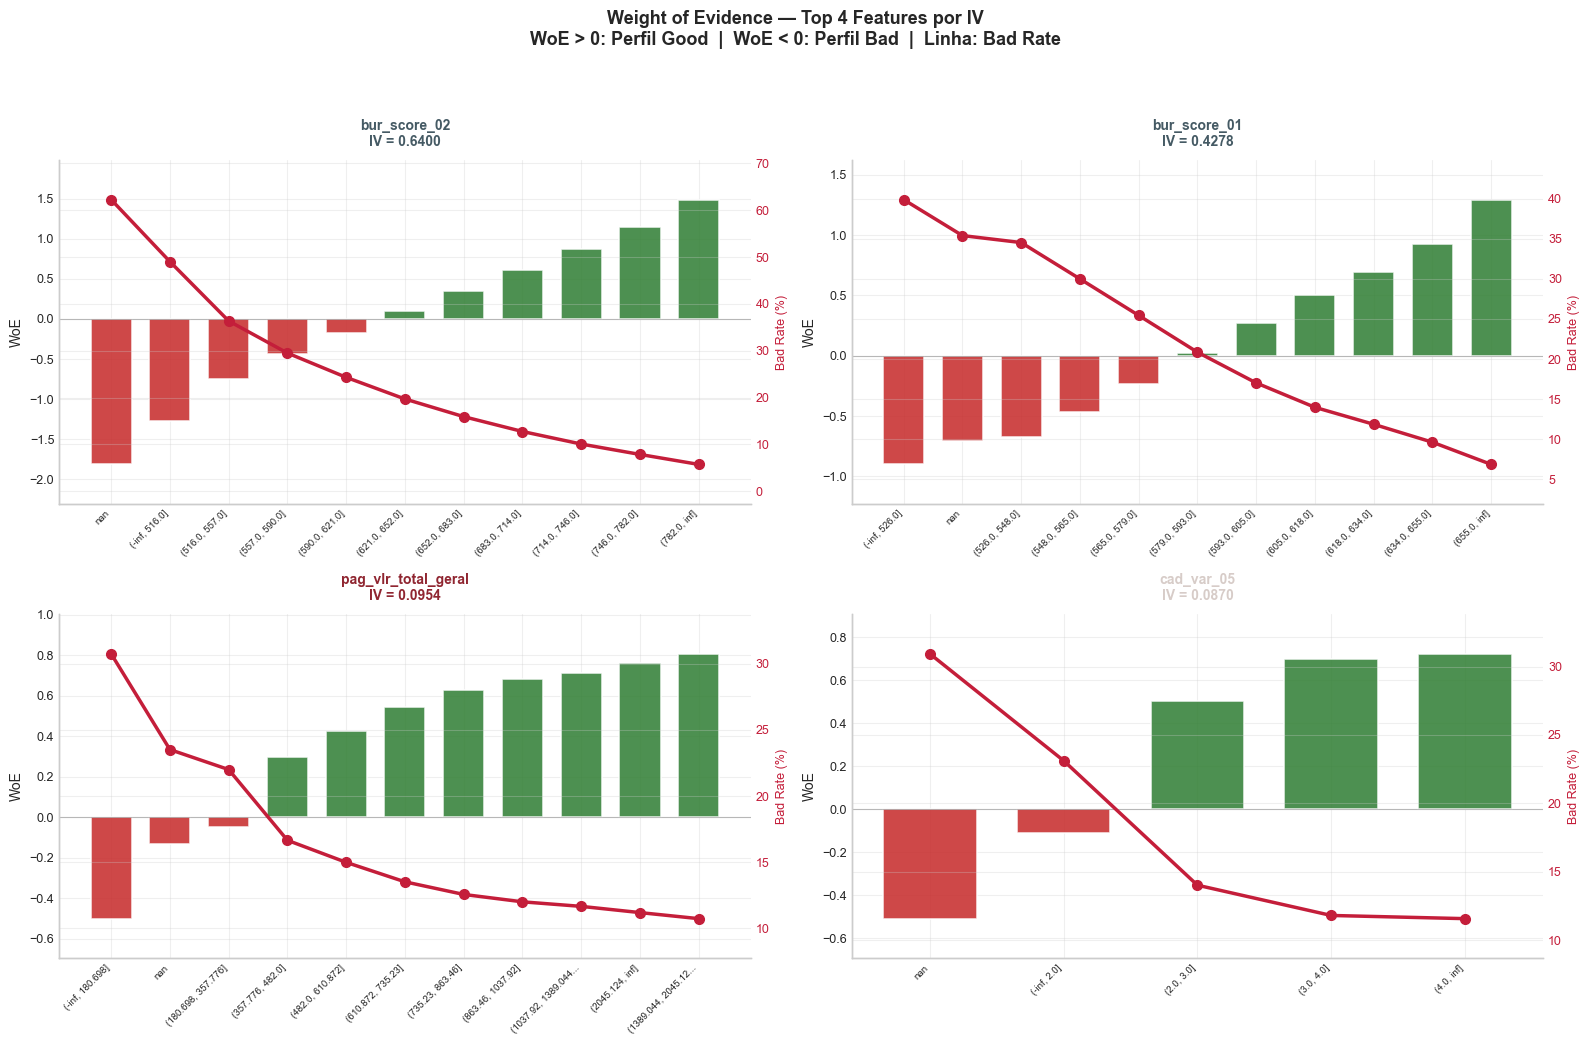

In [186]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()
top4 = iv_summary.head(4)['feature'].tolist()

for ax, feat in zip(axes_flat, top4):
    table = woe_encoder.get_woe_table(feat)
    table = table[table['bin'] != 'MISSING'].sort_values('woe')
    x = range(len(table))

    bar_colors = [COLORS['good'] if w > 0 else COLORS['bad'] for w in table['woe']]
    bars = ax.bar(x, table['woe'], color=bar_colors, edgecolor='white',
                  linewidth=1.2, alpha=0.85, width=0.7)

    ax2 = ax.twinx()
    ax2.plot(x, table['bad_rate'] * 100, marker='o', markersize=7,
             linewidth=2.5, color=COLORS['accent'], zorder=5)
    ax2.set_ylabel('Bad Rate (%)', color=COLORS['accent'], fontsize=9)
    ax2.tick_params(axis='y', labelcolor=COLORS['accent'])

    labels = [b[:18] + '...' if len(str(b)) > 18 else str(b) for b in table['bin']]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('WoE')
    ax.axhline(y=0, color='gray', linewidth=0.8, alpha=0.5)

    domain = feat.split('_')[0] + '_'
    domain_color = colors_domain.get(domain, COLORS['neutral'])
    ax.set_title(f'{feat}\nIV = {woe_encoder.iv_values_[feat]:.4f}',
                 fontweight='bold', fontsize=10, pad=10, color=domain_color)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.suptitle(
    'Weight of Evidence — Top 4 Features por IV\n'
    'WoE > 0: Perfil Good  |  WoE < 0: Perfil Bad  |  Linha: Bad Rate',
    fontsize=13, fontweight='bold', y=1.04
)

for axis in fig.axes:
    axis.margins(y=0.15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_woe_top_features.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 4.1 Correlação entre Features WoE (diagnóstico colinearidade)

DIAGNÓSTICO DE CORRELAÇÃO ENTRE FEATURES WoE

  ⚠️ 24 pares com |r| > 0.7:



,feature_1,feature_2,corr,iv_1,iv_2,acao
17,pag_qtd_faturas_geral,pag_vlr_total_geral,0.865,0.0868,0.0954,Manter pag_vlr_total_geral (maior IV)
11,pag_dias_desde_ultimo_pagamento,pag_vlr_std_l90d,0.863,0.0763,0.0856,Manter pag_vlr_std_l90d (maior IV)
14,pag_ticket_medio_geral,pag_vlr_total_geral,0.860,0.0627,0.0954,Manter pag_vlr_total_geral (maior IV)
21,atr_qtd_faturas_atrasadas_geral,pag_vlr_total_geral,0.839,0.0490,0.0954,Manter pag_vlr_total_geral (maior IV)
15,pag_ticket_medio_geral,pag_vlr_std_l90d,0.839,0.0627,0.0856,Manter pag_vlr_std_l90d (maior IV)
2,pag_share_faturas_com_juros_geral,pag_ticket_medio_geral,0.839,0.0600,0.0627,Manter pag_ticket_medio_geral (maior IV)
6,pag_share_faturas_com_juros_geral,pag_vlr_std_l90d,0.827,0.0600,0.0856,Manter pag_vlr_std_l90d (maior IV)
16,pag_qtd_faturas_geral,atr_qtd_faturas_atrasadas_geral,0.815,0.0868,0.0490,Manter pag_qtd_faturas_geral (maior IV)
13,pag_ticket_medio_geral,atr_qtd_faturas_atrasadas_geral,0.808,0.0627,0.0490,Manter pag_ticket_medio_geral (maior IV)
23,pag_vlr_total_geral,pag_vlr_std_l90d,0.805,0.0954,0.0856,Manter pag_vlr_total_geral (maior IV)



  Features a desprioritizar na seleção: {'pag_share_faturas_com_juros_geral', 'atr_qtd_faturas_atrasadas_geral', 'pag_qtd_faturas_geral', 'pag_vlr_std_l90d', 'bur_score_01', 'pag_ticket_medio_geral', 'pag_dias_desde_ultimo_pagamento', 'atr_vlr_acumulado_geral'}
  → Estas features ainda entram na pool mas com penalidade


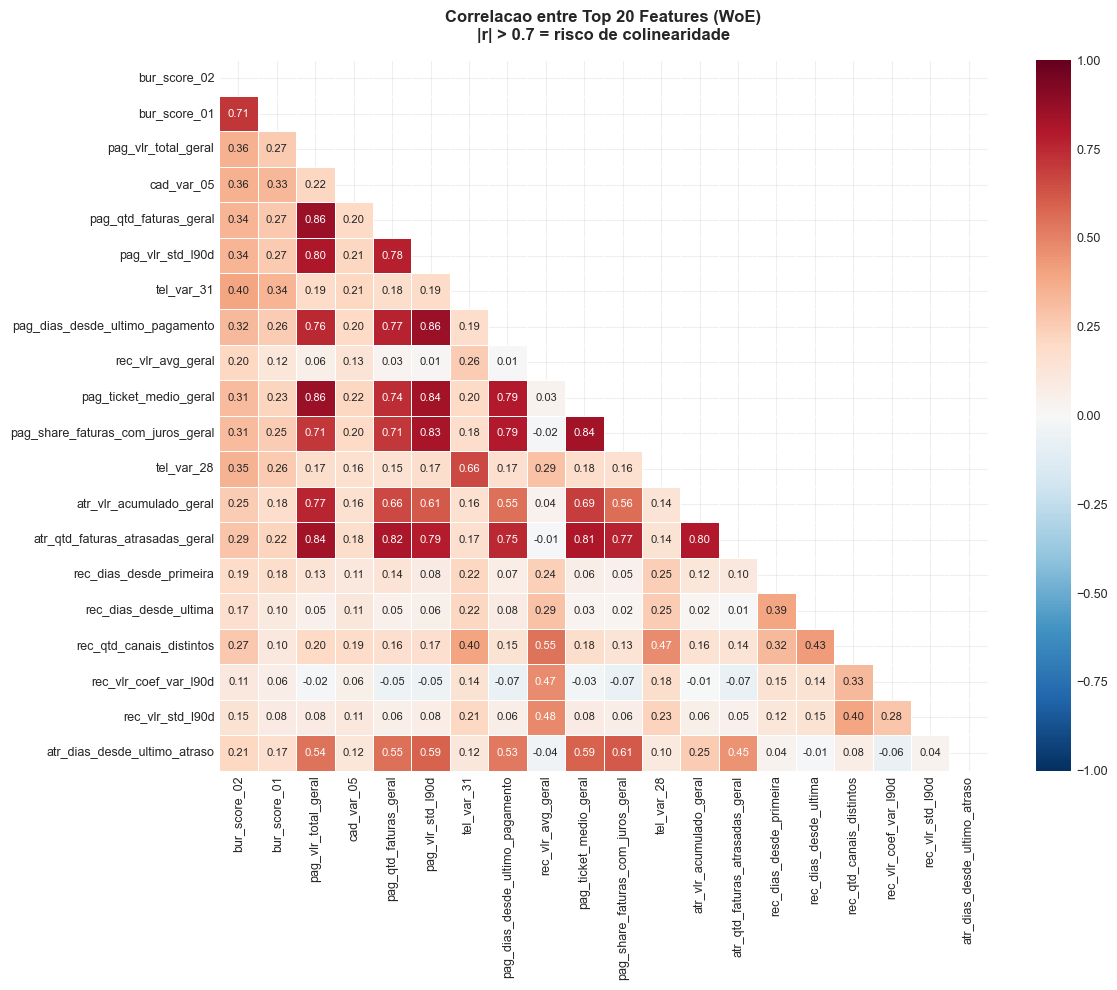

In [187]:
# Features altamente correlacionadas (|r| > 0.7) competem pelos mesmos coeficientes
# e podem gerar sinais invertidos. Identificar ANTES da seleção.

woe_cols_all = [f'{f}_woe' for f in valid_features if f'{f}_woe' in X_train_woe.columns]
corr_matrix = X_train_woe[woe_cols_all].corr()

# Identificar pares altamente correlacionados
high_corr_pairs = []
CORR_THRESHOLD = 0.70

for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > CORR_THRESHOLD:
            f1 = corr_matrix.index[i].replace('_woe', '')
            f2 = corr_matrix.columns[j].replace('_woe', '')
            iv1 = woe_encoder.iv_values_.get(f1, 0)
            iv2 = woe_encoder.iv_values_.get(f2, 0)
            high_corr_pairs.append({
                'feature_1': f1, 'feature_2': f2,
                'corr': r, 'iv_1': iv1, 'iv_2': iv2,
                'acao': f'Manter {f1 if iv1 >= iv2 else f2} (maior IV)'
            })

print("=" * 90)
print("DIAGNÓSTICO DE CORRELAÇÃO ENTRE FEATURES WoE")
print("=" * 90)

if high_corr_pairs:
    print(f"\n  ⚠️ {len(high_corr_pairs)} pares com |r| > {CORR_THRESHOLD}:\n")
    df_corr_pairs = pd.DataFrame(high_corr_pairs).sort_values('corr', key=abs, ascending=False)
    display(df_corr_pairs.style.format({'corr': '{:.3f}', 'iv_1': '{:.4f}', 'iv_2': '{:.4f}'}))

    # Identificar features a remover da candidatura
    features_to_deprioritize = set()
    for _, row in df_corr_pairs.iterrows():
        # Remover a de menor IV do par
        loser = row['feature_1'] if row['iv_1'] < row['iv_2'] else row['feature_2']
        features_to_deprioritize.add(loser)

    print(f"\n  Features a desprioritizar na seleção: {features_to_deprioritize}")
    print(f"  → Estas features ainda entram na pool mas com penalidade")
else:
    print(f"\n  ✅ Nenhum par com |r| > {CORR_THRESHOLD}")
    features_to_deprioritize = set()

# Heatmap das top features
fig, ax = plt.subplots(figsize=(12, 10))
top_n = min(20, len(woe_cols_all))
top_woe = [f'{f}_woe' for f in iv_summary.head(top_n)['feature']
           if f'{f}_woe' in X_train_woe.columns]
corr_top = X_train_woe[top_woe].corr()

corr_top.index = [c.replace('_woe', '') for c in corr_top.index]
corr_top.columns = [c.replace('_woe', '') for c in corr_top.columns]

mask = np.triu(np.ones_like(corr_top, dtype=bool))
sns.heatmap(corr_top, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title(
    f'Correlacao entre Top {top_n} Features (WoE)\n'
    f'|r| > {CORR_THRESHOLD} = risco de colinearidade',
    fontweight='bold', fontsize=12, pad=15
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04b_correlation_woe_features.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 5. Forward Selection com Tracking de KS/Gini

A forward selection adiciona features uma a uma (por IV decrescente) e
mede o ganho incremental em cada etapa. Siddiqi (2017, Cap. 6):

1. Demonstra o **valor marginal** de cada variável
2. Identifica o **ponto de saturação** (ganho < threshold)
3. Revela se as features 🟡 INVESTIGAR trazem ganho real

Critérios de parada

| Critério | Threshold | Referência |
|:---------|:----------|:-----------|
| **Δ Gini mínimo** | < 0.3 pp por feature adicionada | Siddiqi (2017) - ganho marginal irrelevante |
| **Degradação OOT** | > 5 pp vs Test | Thomas (2009) - instabilidade inaceitável |
| **VIF pós-inclusão** | Se piorar significativamente | Anderson (2007) - verificação cruzada |


In [162]:
def calc_metrics(y_true, y_prob):
    """Métricas padrão de credit scoring."""
    auc = roc_auc_score(y_true, y_prob)
    gini = (2 * auc - 1) * 100
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = max(tpr - fpr) * 100
    brier = brier_score_loss(y_true, y_prob)
    return {'auc': auc, 'gini': gini, 'ks': ks, 'brier': brier}

# Ordem de inclusão: IV decrescente (features mais informativas primeiro)
feature_order = iv_summary['feature'].tolist()

print("=" * 100)
print("FORWARD SELECTION - ORDEM DE INCLUSÃO (por IV decrescente)")
print("=" * 100)
for i, feat in enumerate(feature_order, 1):
    iv = woe_encoder.iv_values_.get(feat, 0)
    tipo = feature_type.get(feat, '?')
    emoji = '🟢' if tipo == 'CORE' else '🟡'
    print(f"  {i:2d}. {emoji} {feat:<40s}  IV = {iv:.4f}  [{tipo}]")

FORWARD SELECTION - ORDEM DE INCLUSÃO (por IV decrescente)
   1. 🟢 bur_score_02                              IV = 0.6400  [CORE]
   2. 🟡 bur_score_01                              IV = 0.4278  [INVESTIGAR]
   3. 🟡 pag_vlr_total_geral                       IV = 0.0954  [INVESTIGAR]
   4. 🟢 cad_var_05                                IV = 0.0870  [CORE]
   5. 🟢 pag_qtd_faturas_geral                     IV = 0.0868  [CORE]
   6. 🟡 pag_vlr_std_l90d                          IV = 0.0856  [INVESTIGAR]
   7. 🟢 tel_var_31                                IV = 0.0804  [CORE]
   8. 🟢 pag_dias_desde_ultimo_pagamento           IV = 0.0763  [CORE]
   9. 🟢 rec_vlr_avg_geral                         IV = 0.0724  [CORE]
  10. 🟢 pag_ticket_medio_geral                    IV = 0.0627  [CORE]
  11. 🟢 pag_share_faturas_com_juros_geral         IV = 0.0600  [CORE]
  12. 🟡 tel_var_28                                IV = 0.0594  [INVESTIGAR]
  13. 🟢 atr_vlr_acumulado_geral                   IV = 0.0507  [CORE]
  14. 🟢

In [201]:
MIN_DELTA_KS = 0.15       # pp — threshold mais baixo para permitir mais features
MAX_DEGRADACAO = 5.0       # pp — degradação OOT vs Test
MAX_FEATURES = 25          # Limite prático para Reg. Logística + WoE
MIN_FEATURES_POR_FONTE = 1 # Garantir diversidade

available_woe_cols = [f'{f}_woe' for f in valid_features if f'{f}_woe' in X_train_woe.columns]
available_raw_feats = [f for f in valid_features if f'{f}_woe' in X_train_woe.columns]

selected_cols = []
selected_feats = []
tracking = []
prev_ks_oot = 0.0
prev_gini_oot = 0.0

print("=" * 140)
print("FORWARD SELECTION CONDICIONAL — Critério: Máximo KS OOT incremental")
print("=" * 140)
print(f"\n{'Step':>4} │ {'Feature Adicionada':<42s} │ {'Tipo':<11s} │ "
      f"{'Gini Train':>10s} │ {'Gini Test':>10s} │ {'Gini OOT':>10s} │ "
      f"{'KS OOT':>7s} │ {'Δ KS OOT':>8s} │ {'Degr.':>6s}")
print("─" * 140)

for step in range(1, MAX_FEATURES + 1):
    best_candidate = None
    best_ks_oot = -1
    best_metrics = None

    # Testar cada feature restante
    remaining = [(f, f'{f}_woe') for f in available_raw_feats
                 if f not in selected_feats]

    if not remaining:
        break

    for feat, woe_col in remaining:
        test_cols = selected_cols + [woe_col]

        X_tr = X_train_woe[test_cols].fillna(0)
        X_te = X_test_woe[test_cols].fillna(0)
        X_oo = X_oot_woe[test_cols].fillna(0)

        lr = LogisticRegression(
            penalty='l2', C=1.0,
            class_weight=None,
            solver='lbfgs', max_iter=1000, random_state=42
        )
        lr.fit(X_tr, y_train)

        prob_tr = lr.predict_proba(X_tr)[:, 1]
        prob_te = lr.predict_proba(X_te)[:, 1]
        prob_oo = lr.predict_proba(X_oo)[:, 1]

        m_tr = calc_metrics(y_train, prob_tr)
        m_te = calc_metrics(y_test, prob_te)
        m_oo = calc_metrics(y_oot, prob_oo)

        if m_oo['ks'] > best_ks_oot:
            best_ks_oot = m_oo['ks']
            best_candidate = (feat, woe_col)
            best_metrics = (m_tr, m_te, m_oo)

    if best_candidate is None:
        break

    feat, woe_col = best_candidate
    m_tr, m_te, m_oo = best_metrics

    delta_ks = m_oo['ks'] - prev_ks_oot
    degr = m_te['gini'] - m_oo['gini']
    delta_gini = m_oo['gini'] - prev_gini_oot

    # Critério de parada: se ganho < threshold E já temos features suficientes
    if delta_ks < MIN_DELTA_KS and step > 6:
        # Ainda assim, incluir se for de uma fonte não representada
        fontes_atuais = set(f.split('_')[0] + '_' for f in selected_feats)
        fonte_candidata = feat.split('_')[0] + '_'
        if fonte_candidata in fontes_atuais:
            print(f"\n  ⏹ Parada no step {step}: Δ KS = {delta_ks:+.2f}pp < {MIN_DELTA_KS}pp")
            break
        else:
            print(f"  ℹ️  Incluindo {feat} apesar de Δ KS baixo — fonte {fonte_candidata} não representada")

    selected_cols.append(woe_col)
    selected_feats.append(feat)

    tracking.append({
        'step': step, 'feature': feat, 'woe_col': woe_col,
        'tipo': feature_type.get(feat, ''),
        'n_features': len(selected_cols),
        'gini_train': m_tr['gini'], 'gini_test': m_te['gini'], 'gini_oot': m_oo['gini'],
        'ks_train': m_tr['ks'], 'ks_test': m_te['ks'], 'ks_oot': m_oo['ks'],
        'auc_train': m_tr['auc'], 'auc_test': m_te['auc'], 'auc_oot': m_oo['auc'],
        'brier_train': m_tr['brier'], 'brier_test': m_te['brier'], 'brier_oot': m_oo['brier'],
        'delta_ks_oot': delta_ks, 'delta_gini': delta_gini, 'degradacao': degr,
    })

    emoji = '🟢' if feature_type.get(feat) == 'CORE' else '🟡'
    flag = '  ⚠️' if delta_ks < MIN_DELTA_KS and step > 1 else ''

    print(f"  {step:2d}  │ {emoji} {feat:<39s} │ {feature_type.get(feat, ''):<11s} │ "
          f"{m_tr['gini']:>9.2f}% │ {m_te['gini']:>9.2f}% │ {m_oo['gini']:>9.2f}% │ "
          f"{m_oo['ks']:>6.2f}% │ {delta_ks:>+7.2f}pp │ {degr:>5.2f}%{flag}")

    prev_ks_oot = m_oo['ks']
    prev_gini_oot = m_oo['gini']

df_tracking = pd.DataFrame(tracking)

FORWARD SELECTION CONDICIONAL — Critério: Máximo KS OOT incremental

Step │ Feature Adicionada                         │ Tipo        │ Gini Train │  Gini Test │   Gini OOT │  KS OOT │ Δ KS OOT │  Degr.
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1  │ 🟢 bur_score_02                            │ CORE        │     43.58% │     39.63% │     41.37% │  31.06% │  +31.06pp │ -1.74%
   2  │ 🟢 rec_vlr_avg_geral                       │ CORE        │     44.26% │     40.27% │     42.10% │  31.71% │   +0.65pp │ -1.84%
   3  │ 🟡 bur_score_01                            │ INVESTIGAR  │     44.94% │     41.26% │     42.95% │  32.29% │   +0.57pp │ -1.69%
   4  │ 🟡 rec_ratio_vlr_l30d_l60d                 │ INVESTIGAR  │     45.19% │     41.46% │     43.15% │  32.38% │   +0.10pp │ -1.70%  ⚠️
   5  │ 🟢 rec_dias_desde_ultima                   │ CORE        │     45.32% │     41.60% │     43.29% │  32.53% │   

In [202]:
# Critério composto:
# 1. Degradação < 5pp
# 2. Maximizar KS OOT
# 3. Se empate, preferir mais features (mais robusto para banca)
# 4. Verificar coerência de sinais

df_valid = df_tracking[df_tracking['degradacao'] <= MAX_DEGRADACAO].copy()

if len(df_valid) > 0:
    # Janela: considerar os steps onde KS OOT está a no máximo 0.3pp do máximo
    max_ks = df_valid['ks_oot'].max()
    near_optimal = df_valid[df_valid['ks_oot'] >= max_ks - 0.3]
    # Dentre os near-optimal, preferir mais features (parcimônia invertida — queremos diversidade)
    best_idx = near_optimal['n_features'].idxmax()
else:
    best_idx = df_tracking['ks_oot'].idxmax()

best = df_tracking.loc[best_idx]
optimal_n = int(best['n_features'])
optimal_woe_cols = [r['woe_col'] for _, r in df_tracking.head(optimal_n).iterrows()]
optimal_raw_feats = [r['feature'] for _, r in df_tracking.head(optimal_n).iterrows()]

# --- Verificar coerência de sinais ---
X_tr_check = X_train_woe[optimal_woe_cols].fillna(0)
lr_check = LogisticRegression(
    penalty='l2', C=1.0, class_weight=None,
    solver='lbfgs', max_iter=1000, random_state=42
)
lr_check.fit(X_tr_check, y_train)

print("\n" + "=" * 100)
print("VERIFICAÇÃO DE SINAIS DOS COEFICIENTES")
print("=" * 100)
print("\nEm WoE + Logística, coeficiente NEGATIVO = esperado (WoE alto → Good → menor P(bad))")
print("Coeficiente POSITIVO = possível colinearidade → investigar\n")

sinais_problematicos = []
for feat, woe_col, coef in zip(optimal_raw_feats, optimal_woe_cols, lr_check.coef_[0]):
    sinal = "✅ OK" if coef < 0 else "⚠️ POSITIVO"
    print(f"  {feat:<42s}  coef = {coef:>+8.4f}  {sinal}")
    if coef > 0:
        sinais_problematicos.append(feat)

if sinais_problematicos:
    print(f"\n  🔴 {len(sinais_problematicos)} features com sinal invertido: {sinais_problematicos}")
    print("  → Considerar remover a de menor |coef| e re-rodar")
    print("  → Possível causa: multicolinearidade entre features do mesmo domínio")
else:
    print("\n  ✅ Todos os sinais coerentes — modelo interpretável")

# --- Verificar cobertura de fontes ---
fontes_selecionadas = set(f.split('_')[0] + '_' for f in optimal_raw_feats)
fontes_obrigatorias = {'bur_', 'cad_', 'tel_', 'rec_', 'pag_', 'atr_'}
fontes_faltantes = fontes_obrigatorias - fontes_selecionadas

print(f"\n  Fontes representadas: {fontes_selecionadas}")
if fontes_faltantes:
    print(f"  🔴 Fontes AUSENTES: {fontes_faltantes} — adicionar manualmente")
else:
    print(f"  ✅ Todas as 6 fontes representadas")

# --- Resumo ---
print("\n" + "=" * 100)
print("PONTO ÓTIMO — SELEÇÃO FINAL")
print("=" * 100)
print(f"""
  Step:                    {int(best['step'])}
  N Features:              {optimal_n}

  ┌──────────────────────────────────────────────┐
  │  Gini Train:   {best['gini_train']:>7.2f}%                    │
  │  Gini Test:    {best['gini_test']:>7.2f}%                    │
  │  Gini OOT:     {best['gini_oot']:>7.2f}%  ← validação final │
  │  KS OOT:       {best['ks_oot']:>7.2f}%                    │
  │  Degradação:   {best['degradacao']:>7.2f}pp (Test→OOT)       │
  └──────────────────────────────────────────────┘

  Features selecionadas:
""")

for i, feat in enumerate(optimal_raw_feats, 1):
    tipo = feature_type.get(feat, '')
    iv = woe_encoder.iv_values_.get(feat, 0)
    fonte = feat.split('_')[0] + '_'
    emoji = '🟢' if tipo == 'CORE' else '🟡'
    print(f"    {i:2d}. {emoji} {feat:<38s} IV={iv:.4f}  [{tipo}]  ({fonte})")


VERIFICAÇÃO DE SINAIS DOS COEFICIENTES

Em WoE + Logística, coeficiente NEGATIVO = esperado (WoE alto → Good → menor P(bad))
Coeficiente POSITIVO = possível colinearidade → investigar

  bur_score_02                                coef =  -0.7955  ✅ OK
  rec_vlr_avg_geral                           coef =  -0.4149  ✅ OK
  bur_score_01                                coef =  -0.3105  ✅ OK
  rec_ratio_vlr_l30d_l60d                     coef =  -0.6303  ✅ OK
  rec_dias_desde_ultima                       coef =  -0.3882  ✅ OK
  pag_dias_desde_ultimo_pagamento             coef =  -0.0711  ✅ OK
  tel_var_28                                  coef =  +0.2511  ⚠️ POSITIVO
  atr_vlr_acumulado_geral                     coef =  -0.1464  ✅ OK
  cad_var_02                                  coef =  -0.0840  ✅ OK

  🔴 1 features com sinal invertido: ['tel_var_28']
  → Considerar remover a de menor |coef| e re-rodar
  → Possível causa: multicolinearidade entre features do mesmo domínio

  Fontes representa

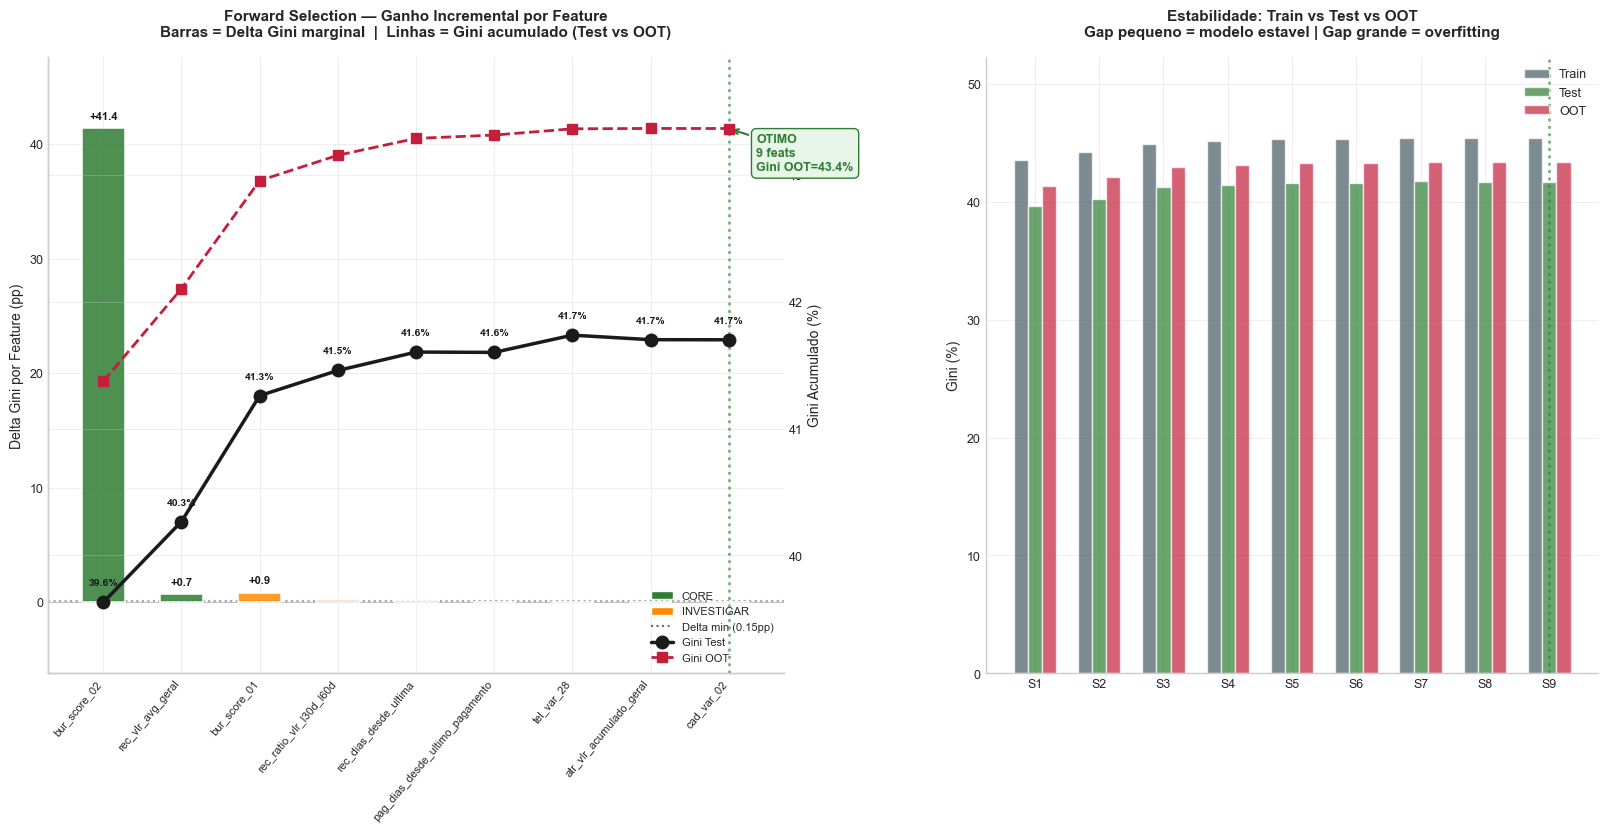

In [203]:
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1], wspace=0.3)

# GRAFICO 1: Evolucao incremental Gini + linha acumulada
ax1 = fig.add_subplot(gs[0])

x = np.arange(len(df_tracking))
bar_colors = [
    COLORS['good'] if t == 'CORE' else COLORS['warn']
    for t in df_tracking['tipo']
]

bars = ax1.bar(x, df_tracking['delta_gini'], color=bar_colors,
               edgecolor='white', linewidth=1.3, alpha=0.85, width=0.55,
               zorder=3)

min_delta_ref = MIN_DELTA_KS
ax1.axhline(y=min_delta_ref, color=COLORS['secondary'], linestyle=':',
            linewidth=1.5, alpha=0.6, label=f'Delta min ({min_delta_ref}pp)')
ax1.axhline(y=0, color='gray', linewidth=0.8, alpha=0.4)

for bar, (_, row) in zip(bars, df_tracking.iterrows()):
    if abs(row['delta_gini']) > 0.3:
        va = 'bottom' if row['delta_gini'] > 0 else 'top'
        offset = 5 if row['delta_gini'] > 0 else -12
        ax1.annotate(
            f'{row["delta_gini"]:+.1f}',
            xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
            xytext=(0, offset), textcoords='offset points',
            ha='center', va=va, fontsize=8, fontweight='bold',
            color=COLORS['primary']
        )

ax1_twin = ax1.twinx()
ax1_twin.plot(x, df_tracking['gini_test'], marker='o', markersize=9,
              linewidth=2.5, color=COLORS['primary'], label='Gini Test',
              zorder=5)
ax1_twin.plot(x, df_tracking['gini_oot'], marker='s', markersize=7,
              linewidth=2, color=COLORS['accent'], linestyle='--',
              label='Gini OOT', zorder=5)

ax1_twin.axvline(x=best_idx, color=COLORS['good'], linewidth=2,
                 linestyle=':', alpha=0.6, zorder=1)
ax1_twin.annotate(
    f'OTIMO\n{optimal_n} feats\nGini OOT={best["gini_oot"]:.1f}%',
    xy=(best_idx, best['gini_oot']),
    xytext=(20, -30), textcoords='offset points',
    fontsize=9, fontweight='bold', color=COLORS['good'],
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor=COLORS['good']),
    arrowprops=dict(arrowstyle='->', color=COLORS['good'], lw=1.5)
)

for i, row in df_tracking.iterrows():
    ax1_twin.annotate(
        f'{row["gini_test"]:.1f}%',
        xy=(i, row['gini_test']),
        xytext=(0, 12), textcoords='offset points',
        ha='center', fontsize=7.5, fontweight='bold', color=COLORS['primary']
    )

ax1.set_xticks(x)
ax1.set_xticklabels(df_tracking['feature'], rotation=50, ha='right', fontsize=8)
ax1.set_ylabel('Delta Gini por Feature (pp)', fontsize=10)
ax1_twin.set_ylabel('Gini Acumulado (%)', fontsize=10)

legend_patches = [
    Patch(facecolor=COLORS['good'], label='CORE', edgecolor='white'),
    Patch(facecolor=COLORS['warn'], label='INVESTIGAR', edgecolor='white'),
    Line2D([0], [0], color=COLORS['secondary'], linestyle=':', label=f'Delta min ({min_delta_ref}pp)'),
]
lines_twin, labels_twin = ax1_twin.get_legend_handles_labels()
ax1_twin.legend(
    handles=legend_patches + lines_twin,
    loc='lower right', fontsize=8, fancybox=True, edgecolor='gray'
)

ax1.set_title(
    'Forward Selection — Ganho Incremental por Feature\n'
    'Barras = Delta Gini marginal  |  Linhas = Gini acumulado (Test vs OOT)',
    fontweight='bold', fontsize=11, pad=15
)
ax1.spines['top'].set_visible(False)

# GRAFICO 2: Estabilidade Train vs Test vs OOT
ax2 = fig.add_subplot(gs[1])

width = 0.22
x2 = np.arange(len(df_tracking))

ax2.bar(x2 - width, df_tracking['gini_train'], width,
        label='Train', color=COLORS['neutral'], alpha=0.7, edgecolor='white')
ax2.bar(x2, df_tracking['gini_test'], width,
        label='Test', color=COLORS['good'], alpha=0.7, edgecolor='white')
ax2.bar(x2 + width, df_tracking['gini_oot'], width,
        label='OOT', color=COLORS['accent'], alpha=0.7, edgecolor='white')

ax2.axvline(x=best_idx, color=COLORS['good'], linewidth=2, linestyle=':', alpha=0.6)

ax2.set_xticks(x2)
ax2.set_xticklabels([f'S{s}' for s in df_tracking['step']], fontsize=9)
ax2.set_ylabel('Gini (%)', fontsize=10)
ax2.set_title(
    'Estabilidade: Train vs Test vs OOT\n'
    'Gap pequeno = modelo estavel | Gap grande = overfitting',
    fontweight='bold', fontsize=11, pad=15
)
ax2.legend(loc='upper right', fontsize=9, fancybox=True, edgecolor='gray')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for axis in fig.axes:
    axis.margins(y=0.15)

plt.savefig(FIGURES_DIR / '02_forward_selection_tracking.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


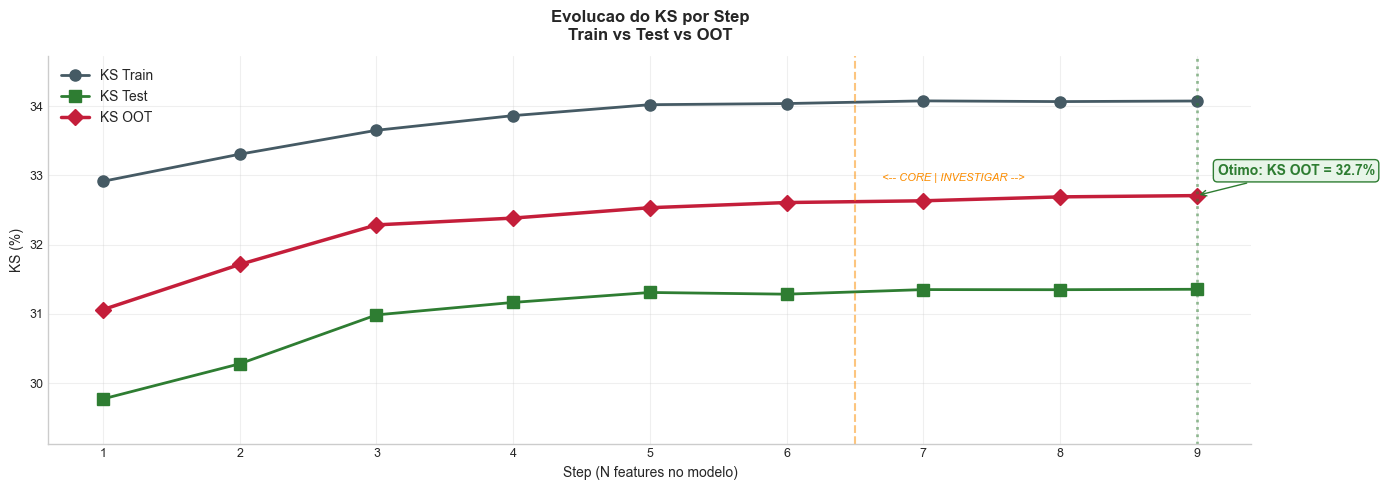

In [192]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_tracking['step'], df_tracking['ks_train'], marker='o', markersize=8,
        linewidth=2, color=COLORS['neutral'], label='KS Train')
ax.plot(df_tracking['step'], df_tracking['ks_test'], marker='s', markersize=8,
        linewidth=2, color=COLORS['good'], label='KS Test')
ax.plot(df_tracking['step'], df_tracking['ks_oot'], marker='D', markersize=8,
        linewidth=2.5, color=COLORS['accent'], label='KS OOT')

ax.axvline(x=int(best['step']), color=COLORS['good'], linewidth=2,
           linestyle=':', alpha=0.5)
ax.annotate(
    f'Otimo: KS OOT = {best["ks_oot"]:.1f}%',
    xy=(int(best['step']), best['ks_oot']),
    xytext=(15, 15), textcoords='offset points',
    fontsize=10, fontweight='bold', color=COLORS['good'],
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F5E9', edgecolor=COLORS['good']),
    arrowprops=dict(arrowstyle='->', color=COLORS['good'])
)

# Separacao visual CORE / INVESTIGAR (sem emoji)
n_core = sum(1 for _, r in df_tracking.iterrows()
             if r['step'] <= optimal_n and r['tipo'] == 'CORE')
if n_core < len(df_tracking):
    ax.axvline(x=n_core + 0.5, color=COLORS['warn'], linewidth=1.5,
               linestyle='--', alpha=0.5)
    ax.text(n_core + 0.7, ax.get_ylim()[1] * 0.96,
            '<-- CORE | INVESTIGAR -->',
            fontsize=8, color=COLORS['warn'], fontstyle='italic')

ax.set_xlabel('Step (N features no modelo)', fontsize=10)
ax.set_ylabel('KS (%)', fontsize=10)
ax.set_title(
    'Evolucao do KS por Step\nTrain vs Test vs OOT',
    fontweight='bold', fontsize=12, pad=12
)
ax.set_xticks(df_tracking['step'])
ax.legend(fontsize=10, fancybox=True, edgecolor='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.margins(y=0.15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02b_ks_evolution.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 6. Modelo Baseline Final

In [169]:
# Treinamos o modelo final com as features do ponto ótimo.
# Este é o modelo exportado como `.pkl` para a banca.

X_tr_final = X_train_woe[optimal_woe_cols].fillna(0)
X_te_final = X_test_woe[optimal_woe_cols].fillna(0)
X_oo_final = X_oot_woe[optimal_woe_cols].fillna(0)

model_woe = LogisticRegression(
    penalty='l2', C=1.0, class_weight=None,
    solver='lbfgs', max_iter=1000, random_state=42
)
model_woe.fit(X_tr_final, y_train)

prob_train_woe = model_woe.predict_proba(X_tr_final)[:, 1]
prob_test_woe  = model_woe.predict_proba(X_te_final)[:, 1]
prob_oot_woe   = model_woe.predict_proba(X_oo_final)[:, 1]

m_tr_woe = calc_metrics(y_train, prob_train_woe)
m_te_woe = calc_metrics(y_test, prob_test_woe)
m_oo_woe = calc_metrics(y_oot, prob_oot_woe)

# Coeficientes
coef_df = pd.DataFrame({
    'feature': optimal_raw_feats,
    'woe_col': optimal_woe_cols,
    'coef': model_woe.coef_[0],
    'abs_coef': np.abs(model_woe.coef_[0]),
    'tipo': [feature_type.get(f, '') for f in optimal_raw_feats],
    'iv': [woe_encoder.iv_values_.get(f, 0) for f in optimal_raw_feats]
}).sort_values('abs_coef', ascending=False)

print("=" * 90)
print("MODELO BASELINE — COEFICIENTES")
print("=" * 90)
print(f"\n  Intercepto: {model_woe.intercept_[0]:.4f}")
print(f"  Features:   {len(optimal_woe_cols)}")
print(f"  Regularização: L2 (C=1.0)\n")

display(coef_df[['feature', 'tipo', 'iv', 'coef', 'abs_coef']].style.format({
    'coef': '{:.4f}', 'abs_coef': '{:.4f}', 'iv': '{:.4f}'
}).background_gradient(subset=['abs_coef'], cmap='OrRd'))


MODELO BASELINE — COEFICIENTES

  Intercepto: -1.3135
  Features:   9
  Regularização: L2 (C=1.0)



,feature,tipo,iv,coef,abs_coef
0,bur_score_02,CORE,0.6400,-0.7955,0.7955
3,rec_ratio_vlr_l30d_l60d,INVESTIGAR,0.0232,-0.6303,0.6303
1,rec_vlr_avg_geral,CORE,0.0724,-0.4149,0.4149
4,rec_dias_desde_ultima,CORE,0.0401,-0.3882,0.3882
2,bur_score_01,INVESTIGAR,0.4278,-0.3105,0.3105
6,tel_var_28,INVESTIGAR,0.0594,0.2511,0.2511
7,atr_vlr_acumulado_geral,CORE,0.0507,-0.1464,0.1464
8,cad_var_02,CORE,0.0060,-0.0840,0.0840
5,pag_dias_desde_ultimo_pagamento,CORE,0.0763,-0.0711,0.0711


In [170]:
# Validação de sinais
# Em WoE-encoded Logistic Regression, coeficientes NEGATIVOS significam:
# "quanto maior o WoE (perfil Good), MENOR a probabilidade de Bad"
# → isso é o esperado

n_pos = (coef_df['coef'] > 0).sum()
n_neg = (coef_df['coef'] < 0).sum()
print(f"\n  Coeficientes negativos (esperado): {n_neg}")
print(f"  Coeficientes positivos (atenção):  {n_pos}")
if n_pos == 0:
    print("  ✅ Todos os sinais consistentes — modelo estável")
else:
    print("  ⚠️ Coeficientes positivos detectados — verificar monotonicidade do WoE")


  Coeficientes negativos (esperado): 8
  Coeficientes positivos (atenção):  1
  ⚠️ Coeficientes positivos detectados — verificar monotonicidade do WoE


# 7. Comparativo: WoE vs Label Encoding Simples

Para demonstrar o ganho do WoE, treinamos o mesmo modelo com encoding simples (valores originais + StandardScaler + mediana para missings).

In [ ]:
X_tr_simple = df_train[optimal_raw_feats].copy()
X_te_simple = df_test[optimal_raw_feats].copy()
X_oo_simple = df_oot[optimal_raw_feats].copy()

medians = X_tr_simple.median()
X_tr_simple = X_tr_simple.fillna(medians)
X_te_simple = X_te_simple.fillna(medians)
X_oo_simple = X_oo_simple.fillna(medians)

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_simple)
X_te_scaled = scaler.transform(X_te_simple)
X_oo_scaled = scaler.transform(X_oo_simple)

model_simple = LogisticRegression(
    penalty='l2', C=1.0, class_weight=None,
    solver='lbfgs', max_iter=1000, random_state=42
)
model_simple.fit(X_tr_scaled, y_train)

prob_train_simple = model_simple.predict_proba(X_tr_scaled)[:, 1]
prob_test_simple  = model_simple.predict_proba(X_te_scaled)[:, 1]
prob_oot_simple   = model_simple.predict_proba(X_oo_scaled)[:, 1]

m_tr_simple = calc_metrics(y_train, prob_train_simple)
m_te_simple = calc_metrics(y_test, prob_test_simple)
m_oo_simple = calc_metrics(y_oot, prob_oot_simple)

comp = pd.DataFrame({
    'Métrica': ['Gini (%)', 'KS (%)', 'AUC', 'Brier Score'],
    'WoE Train': [m_tr_woe['gini'], m_tr_woe['ks'], m_tr_woe['auc'], m_tr_woe['brier']],
    'WoE Test':  [m_te_woe['gini'], m_te_woe['ks'], m_te_woe['auc'], m_te_woe['brier']],
    'WoE OOT':   [m_oo_woe['gini'], m_oo_woe['ks'], m_oo_woe['auc'], m_oo_woe['brier']],
    'Simple Train': [m_tr_simple['gini'], m_tr_simple['ks'], m_tr_simple['auc'], m_tr_simple['brier']],
    'Simple Test':  [m_te_simple['gini'], m_te_simple['ks'], m_te_simple['auc'], m_te_simple['brier']],
    'Simple OOT':   [m_oo_simple['gini'], m_oo_simple['ks'], m_oo_simple['auc'], m_oo_simple['brier']],
})
comp['Ganho WoE (OOT)'] = comp['WoE OOT'] - comp['Simple OOT']

print("=" * 90)
print("COMPARATIVO: WoE vs LABEL ENCODING SIMPLES")
print("=" * 90)
print("\nSiddiqi (2017, Cap. 5): WoE lineariza a relação com o target,")
print("maximizando a performance da Regressão Logística.\n")

display(comp.style.format({
    'WoE Train': '{:.2f}', 'WoE Test': '{:.2f}', 'WoE OOT': '{:.2f}',
    'Simple Train': '{:.2f}', 'Simple Test': '{:.2f}', 'Simple OOT': '{:.2f}',
    'Ganho WoE (OOT)': '{:+.2f}'
}).background_gradient(subset=['Ganho WoE (OOT)'], cmap='RdYlGn'))

COMPARATIVO: WoE vs LABEL ENCODING SIMPLES

Siddiqi (2017, Cap. 5): WoE lineariza a relação com o target,
maximizando a performance da Regressão Logística.



,Métrica,WoE Train,WoE Test,WoE OOT,Simple Train,Simple Test,Simple OOT,Ganho WoE (OOT)
0,Gini (%),45.43,41.70,43.36,44.87,41.03,42.58,+0.79
1,KS (%),34.08,31.36,32.71,33.40,30.56,31.80,+0.91
2,AUC,0.73,0.71,0.72,0.72,0.71,0.71,+0.00
3,Brier Score,0.15,0.15,0.15,0.21,0.21,0.21,-0.06


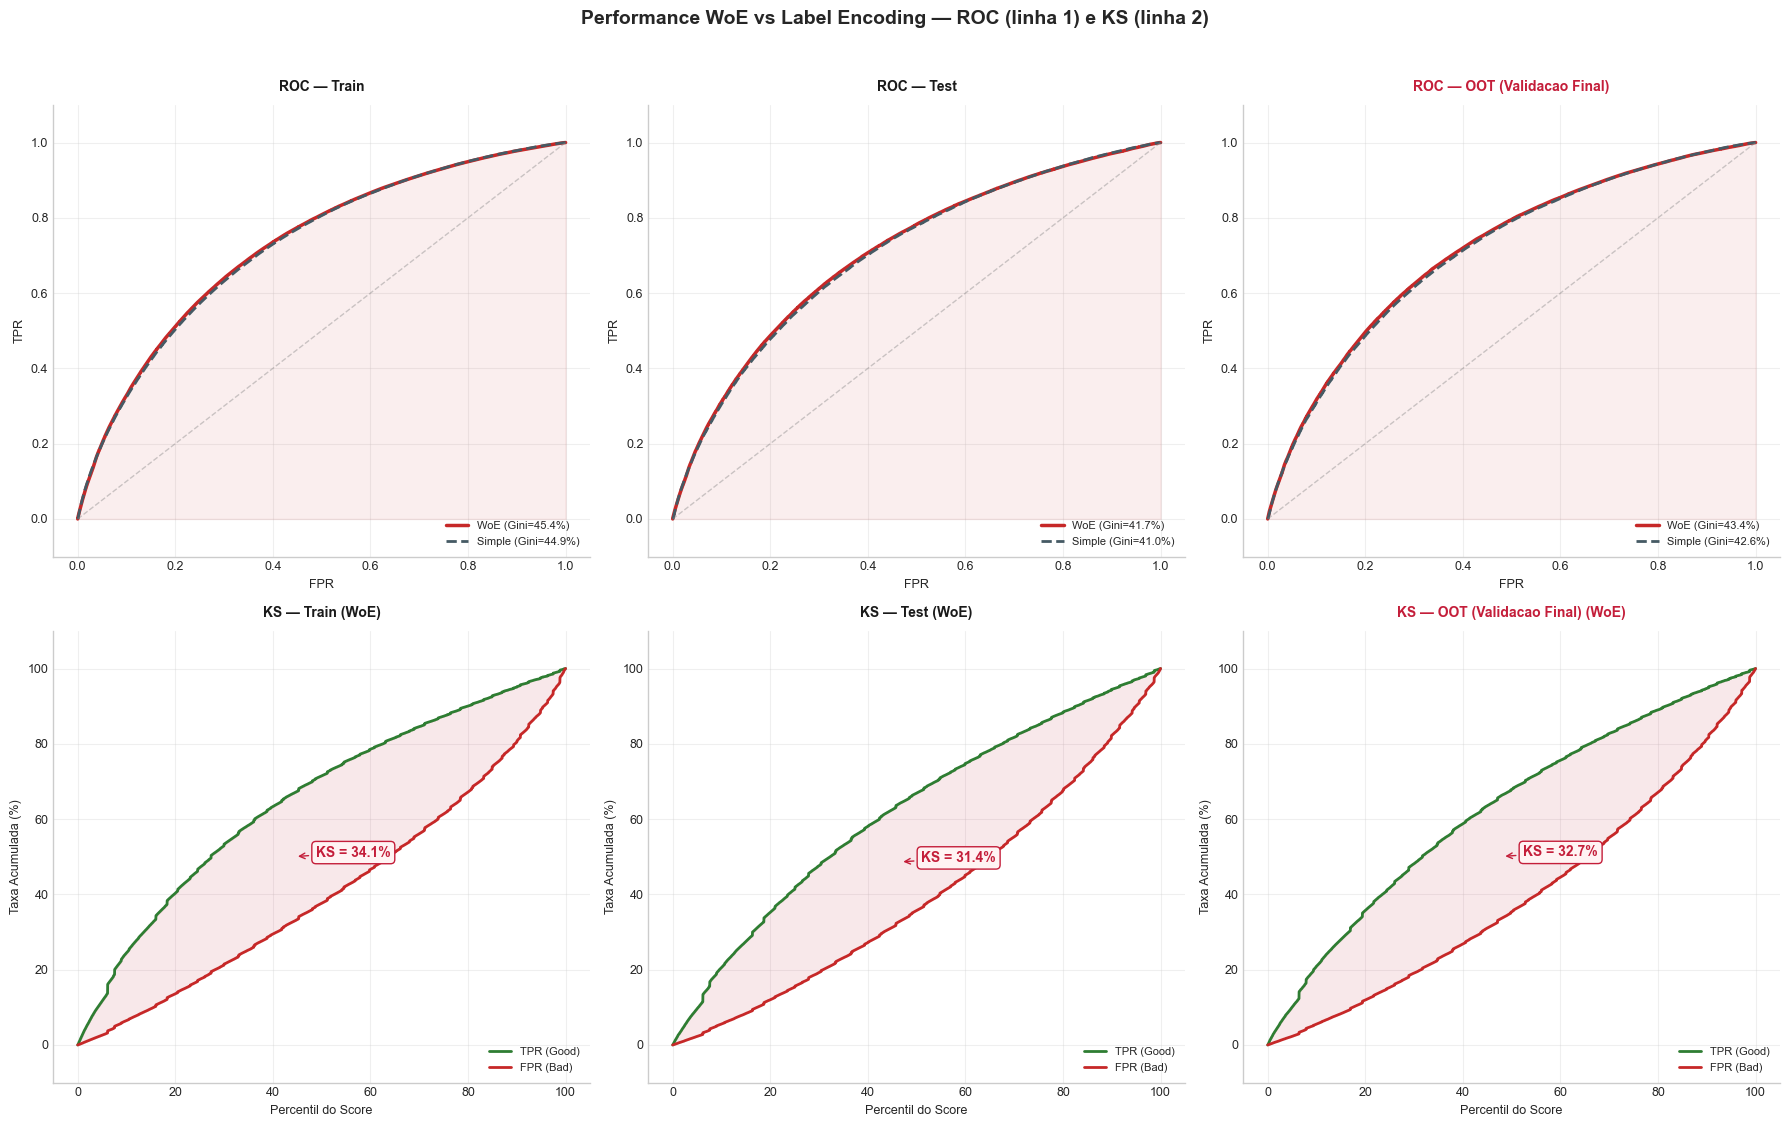

In [193]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

titles = ['Train', 'Test', 'OOT (Validacao Final)']
probs_w = [prob_train_woe, prob_test_woe, prob_oot_woe]
probs_s = [prob_train_simple, prob_test_simple, prob_oot_simple]
y_sets  = [y_train, y_test, y_oot]
mw_list = [m_tr_woe, m_te_woe, m_oo_woe]
ms_list = [m_tr_simple, m_te_simple, m_oo_simple]

# --- Linha 1: ROC Curves ---
for col, (title, pw, ps, ys, mw, ms) in enumerate(
    zip(titles, probs_w, probs_s, y_sets, mw_list, ms_list)
):
    ax = axes[0, col]
    fpr_w, tpr_w, _ = roc_curve(ys, pw)
    fpr_s, tpr_s, _ = roc_curve(ys, ps)

    ax.plot(fpr_w, tpr_w, linewidth=2.5, color=COLORS['bad'],
            label=f'WoE (Gini={mw["gini"]:.1f}%)')
    ax.plot(fpr_s, tpr_s, linewidth=2, color=COLORS['neutral'], linestyle='--',
            label=f'Simple (Gini={ms["gini"]:.1f}%)')
    ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, alpha=0.4)
    ax.fill_between(fpr_w, tpr_w, alpha=0.08, color=COLORS['bad'])

    is_oot = 'OOT' in title
    ax.set_title(f'ROC — {title}', fontweight='bold', fontsize=10, pad=10,
                 color=COLORS['accent'] if is_oot else COLORS['primary'])
    ax.set_xlabel('FPR', fontsize=9)
    ax.set_ylabel('TPR', fontsize=9)
    ax.legend(loc='lower right', fontsize=8, fancybox=True, edgecolor='gray')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# --- Linha 2: KS Curves ---
for col, (title, pw, ps, ys, mw, ms) in enumerate(
    zip(titles, probs_w, probs_s, y_sets, mw_list, ms_list)
):
    ax = axes[1, col]
    fpr_w, tpr_w, thresholds_w = roc_curve(ys, pw)
    ks_curve_w = tpr_w - fpr_w
    ks_max_idx_w = np.argmax(ks_curve_w)

    pct = np.linspace(0, 100, len(fpr_w))

    ax.plot(pct, tpr_w * 100, linewidth=2, color=COLORS['good'], label='TPR (Good)')
    ax.plot(pct, fpr_w * 100, linewidth=2, color=COLORS['bad'], label='FPR (Bad)')
    ax.fill_between(pct, tpr_w * 100, fpr_w * 100, alpha=0.1, color=COLORS['accent'])

    ax.annotate(
        f'KS = {mw["ks"]:.1f}%',
        xy=(pct[ks_max_idx_w], (tpr_w[ks_max_idx_w] + fpr_w[ks_max_idx_w]) / 2 * 100),
        xytext=(15, 0), textcoords='offset points',
        fontsize=10, fontweight='bold', color=COLORS['accent'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3F3', edgecolor=COLORS['accent']),
        arrowprops=dict(arrowstyle='->', color=COLORS['accent'])
    )

    is_oot = 'OOT' in title
    ax.set_title(f'KS — {title} (WoE)', fontweight='bold', fontsize=10, pad=10,
                 color=COLORS['accent'] if is_oot else COLORS['primary'])
    ax.set_xlabel('Percentil do Score', fontsize=9)
    ax.set_ylabel('Taxa Acumulada (%)', fontsize=9)
    ax.legend(loc='lower right', fontsize=8, fancybox=True, edgecolor='gray')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'Performance WoE vs Label Encoding — ROC (linha 1) e KS (linha 2)',
    fontsize=14, fontweight='bold', y=1.02
)

for axis in fig.axes:
    axis.margins(y=0.1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_roc_ks_comparativo.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 8. Gains Table (Tabela de Decis)

A gains table traduz o poder discriminatório em **decisões de política
de crédito** (Siddiqi, 2017, Cap. 7; Thomas, 2009, Cap. 7).

- Decil 10 = maior probabilidade de Bad (pior risco)
- Decil 1 = menor probabilidade de Bad (melhor risco)
- **Monotonicidade** da Bad Rate é requisito fundamental

In [173]:
def create_gains_table(y_true, y_prob, n_bins=10, label=''):
    """Gains table padrão de credit scoring (Siddiqi, 2017, Cap. 7)."""
    tmp = pd.DataFrame({'y': y_true, 'prob': y_prob})
    tmp['decil'] = pd.qcut(tmp['prob'], q=n_bins, labels=False, duplicates='drop') + 1

    gt = tmp.groupby('decil').agg(
        n=('y', 'count'),
        n_bad=('y', 'sum'),
        prob_min=('prob', 'min'),
        prob_max=('prob', 'max'),
        prob_mean=('prob', 'mean')
    ).reset_index()

    total_n, total_bad = gt['n'].sum(), gt['n_bad'].sum()
    gt['n_good'] = gt['n'] - gt['n_bad']
    gt['bad_rate'] = gt['n_bad'] / gt['n']
    gt['pct_total'] = gt['n'] / total_n
    gt['pct_bad']  = gt['n_bad'] / total_bad
    gt['pct_good'] = gt['n_good'] / (total_n - total_bad)

    # Acumulados do pior decil (10) para o melhor (1)
    gt_sorted = gt.sort_values('decil', ascending=False)
    gt_sorted['cum_n'] = gt_sorted['n'].cumsum()
    gt_sorted['cum_bad'] = gt_sorted['n_bad'].cumsum()
    gt_sorted['cum_good'] = gt_sorted['n_good'].cumsum()
    gt_sorted['cum_pct_total'] = gt_sorted['cum_n'] / total_n
    gt_sorted['cum_pct_bad']  = gt_sorted['cum_bad'] / total_bad
    gt_sorted['cum_pct_good'] = gt_sorted['cum_good'] / (total_n - total_bad)
    gt_sorted['cum_bad_rate'] = gt_sorted['cum_bad'] / gt_sorted['cum_n']
    gt_sorted['lift'] = gt_sorted['cum_pct_bad'] / gt_sorted['cum_pct_total']

    gt_sorted = gt_sorted.sort_values('decil')
    gt_sorted['conjunto'] = label
    return gt_sorted

# Gains tables
gt_train = create_gains_table(y_train, prob_train_woe, label='Train')
gt_test  = create_gains_table(y_test, prob_test_woe, label='Test')
gt_oot   = create_gains_table(y_oot, prob_oot_woe, label='OOT')

print("=" * 100)
print("GAINS TABLE — OOT (VALIDAÇÃO FINAL)")
print("=" * 100)

display(gt_oot[[
    'decil', 'n', 'n_bad', 'bad_rate', 'prob_min', 'prob_max',
    'cum_pct_total', 'cum_pct_bad', 'cum_bad_rate', 'lift'
]].style.format({
    'n': '{:,.0f}', 'n_bad': '{:,.0f}', 'bad_rate': '{:.1%}',
    'prob_min': '{:.4f}', 'prob_max': '{:.4f}',
    'cum_pct_total': '{:.1%}', 'cum_pct_bad': '{:.1%}',
    'cum_bad_rate': '{:.1%}', 'lift': '{:.2f}x'
}).background_gradient(subset=['bad_rate'], cmap='RdYlGn_r')
  .background_gradient(subset=['lift'], cmap='RdYlGn'))

GAINS TABLE — OOT (VALIDAÇÃO FINAL)


,decil,n,n_bad,bad_rate,prob_min,prob_max,cum_pct_total,cum_pct_bad,cum_bad_rate,lift
0,1,"43,603","2,802",6.4%,0.0313,0.0620,100.0%,100.0%,21.5%,1.00x
1,2,"44,316","3,817",8.6%,0.0620,0.0835,90.0%,97.0%,23.1%,1.08x
2,3,"43,516","4,646",10.7%,0.0835,0.1079,79.8%,92.9%,25.0%,1.16x
3,4,"42,972","5,521",12.8%,0.1079,0.1383,69.9%,88.0%,27.0%,1.26x
4,5,"43,591","6,927",15.9%,0.1383,0.1742,60.0%,82.1%,29.4%,1.37x
5,6,"44,480","8,718",19.6%,0.1742,0.2179,50.0%,74.7%,32.1%,1.49x
6,7,"42,719","10,361",24.3%,0.2179,0.2672,39.8%,65.4%,35.3%,1.64x
7,8,"43,603","13,092",30.0%,0.2672,0.3262,30.0%,54.3%,38.9%,1.81x
8,9,"43,613","16,013",36.7%,0.3262,0.4153,20.0%,40.3%,43.3%,2.02x
9,10,"43,583","21,721",49.8%,0.4153,0.6902,10.0%,23.2%,49.8%,2.32x


In [174]:
bad_rates = gt_oot.sort_values('decil')['bad_rate'].values
is_monotonic = all(bad_rates[i] <= bad_rates[i+1] for i in range(len(bad_rates)-1))
print(f"\n{'✅' if is_monotonic else '⚠️'} Monotonicidade da Bad Rate: {'OK' if is_monotonic else 'VERIFICAR'}")
print(f"  Decil 1 (melhor risco):  {bad_rates[0]:.1%}")
print(f"  Decil 10 (pior risco):   {bad_rates[-1]:.1%}")
print(f"  Razão D10/D1:            {bad_rates[-1]/max(bad_rates[0], 0.001):.1f}x")


✅ Monotonicidade da Bad Rate: OK
  Decil 1 (melhor risco):  6.4%
  Decil 10 (pior risco):   49.8%
  Razão D10/D1:            7.8x


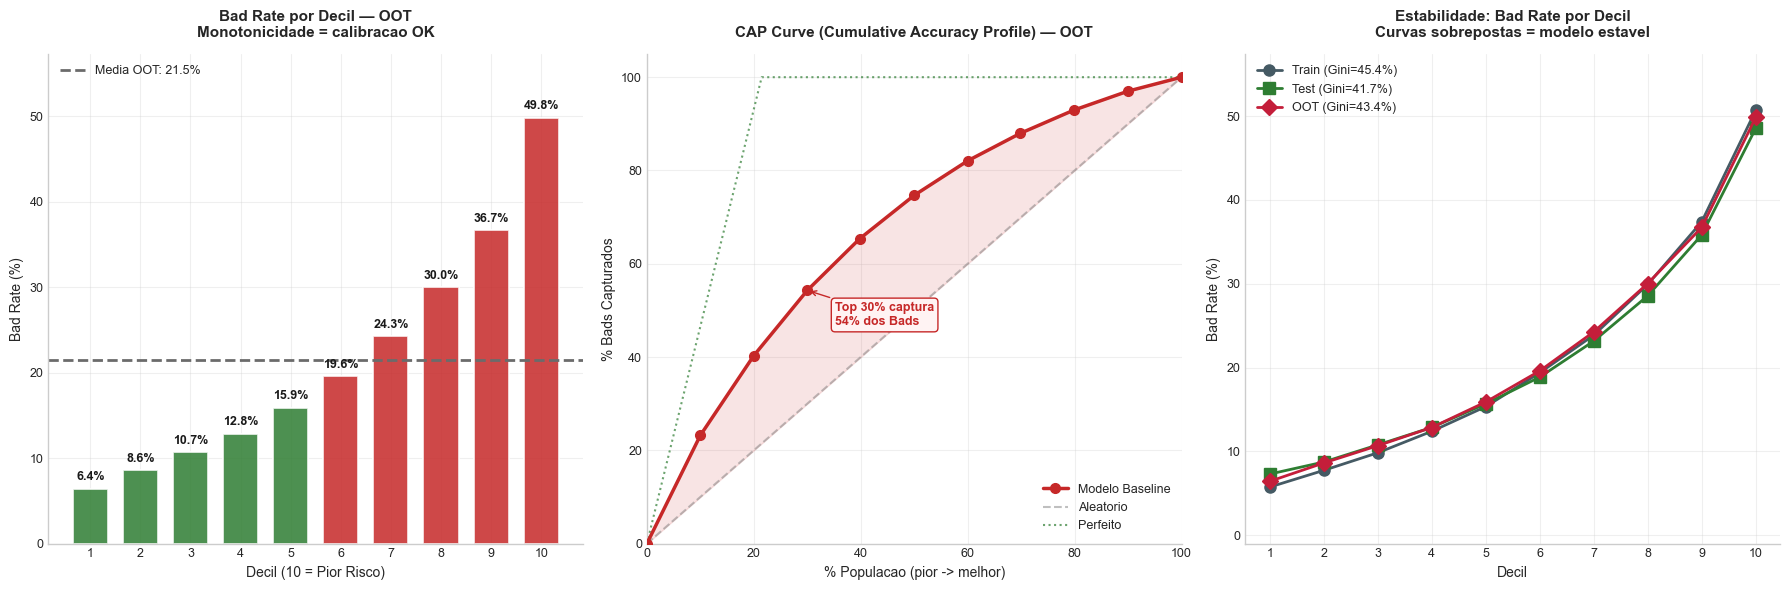

In [200]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grafico 1: Bad Rate por Decil
ax1 = axes[0]
decis = gt_oot.sort_values('decil')
avg_br = y_oot.mean() * 100

bar_colors = [COLORS['bad'] if br > decis['bad_rate'].median()
              else COLORS['good'] for br in decis['bad_rate']]

bars = ax1.bar(decis['decil'], decis['bad_rate'] * 100, color=bar_colors,
               edgecolor='white', linewidth=1.3, alpha=0.85, width=0.7)

ax1.axhline(y=avg_br, color=COLORS['secondary'], linestyle='--', linewidth=2,
            label=f'Media OOT: {avg_br:.1f}%')

for bar, (_, row) in zip(bars, decis.iterrows()):
    ax1.annotate(f'{row["bad_rate"]*100:.1f}%',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 6), textcoords='offset points',
                 ha='center', fontsize=9, fontweight='bold', color=COLORS['primary'])

ax1.set_xlabel('Decil (10 = Pior Risco)', fontsize=10)
ax1.set_ylabel('Bad Rate (%)', fontsize=10)
ax1.set_title('Bad Rate por Decil — OOT\nMonotonicidade = calibracao OK',
              fontweight='bold', fontsize=11, pad=12)
ax1.set_xticks(range(1, 11))
ax1.legend(loc='upper left', fontsize=9, fancybox=True, edgecolor='gray')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Grafico 2: CAP Curve
ax2 = axes[1]

gt_cap = gt_oot.sort_values('decil', ascending=False)
cum_pop = np.concatenate([[0], gt_cap['cum_pct_total'].values])
cum_bad = np.concatenate([[0], gt_cap['cum_pct_bad'].values])

ax2.plot(cum_pop * 100, cum_bad * 100, marker='o', markersize=7,
         linewidth=2.5, color=COLORS['bad'], label='Modelo Baseline', zorder=5)
ax2.plot([0, 100], [0, 100], '--', color='gray', linewidth=1.5,
         label='Aleatorio', alpha=0.5)

bad_rate_global = y_oot.mean()
perfect_x = [0, bad_rate_global * 100, 100]
perfect_y = [0, 100, 100]
ax2.plot(perfect_x, perfect_y, ':', color=COLORS['good'], linewidth=1.5,
         label='Perfeito', alpha=0.7)

ax2.fill_between(cum_pop * 100, cum_bad * 100, cum_pop * 100,
                 alpha=0.12, color=COLORS['bad'])

idx_30 = np.argmin(np.abs(cum_pop - 0.30))
if idx_30 < len(cum_bad):
    ax2.annotate(
        f'Top 30% captura\n{cum_bad[idx_30]*100:.0f}% dos Bads',
        xy=(cum_pop[idx_30]*100, cum_bad[idx_30]*100),
        xytext=(20, -25), textcoords='offset points',
        fontsize=9, fontweight='bold', color=COLORS['bad'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3F3', edgecolor=COLORS['bad']),
        arrowprops=dict(arrowstyle='->', color=COLORS['bad'])
    )

ax2.set_xlabel('% Populacao (pior -> melhor)', fontsize=10)
ax2.set_ylabel('% Bads Capturados', fontsize=10)
ax2.set_title('CAP Curve (Cumulative Accuracy Profile) — OOT',
              fontweight='bold', fontsize=11, pad=12)
ax2.legend(loc='lower right', fontsize=9, fancybox=True, edgecolor='gray')
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Grafico 3: Estabilidade entre conjuntos
ax3 = axes[2]

for gt, label, color, marker in [
    (gt_train, 'Train', COLORS['neutral'], 'o'),
    (gt_test,  'Test',  COLORS['good'],    's'),
    (gt_oot,   'OOT',   COLORS['accent'],  'D'),
]:
    gt_s = gt.sort_values('decil')
    y_set = y_train if label == 'Train' else y_test if label == 'Test' else y_oot
    prob_set = prob_train_woe if label == 'Train' else prob_test_woe if label == 'Test' else prob_oot_woe
    gini_val = calc_metrics(y_set, prob_set)['gini']

    ax3.plot(gt_s['decil'], gt_s['bad_rate'] * 100, marker=marker, markersize=8,
             linewidth=2, color=color, label=f'{label} (Gini={gini_val:.1f}%)')

ax3.set_xlabel('Decil', fontsize=10)
ax3.set_ylabel('Bad Rate (%)', fontsize=10)
ax3.set_title('Estabilidade: Bad Rate por Decil\nCurvas sobrepostas = modelo estavel',
              fontweight='bold', fontsize=11, pad=12)
ax3.set_xticks(range(1, 11))
ax3.legend(loc='upper left', fontsize=9, fancybox=True, edgecolor='gray')
ax3.grid(True, alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

for axis in fig.axes:
    axis.margins(y=0.15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_gains_table_modelo_final.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 9. PSI

In [ ]:
# O Population Stability Index (PSI) mede se a distribuição do score
# mudou entre Train e OOT. Siddiqi (2017, Cap. 9):

# | PSI | Interpretação |
# |:----|:-------------|
# | < 0.10 | ✅ Estável |
# | 0.10 – 0.25 | ⚠️ Leve deslocamento — monitorar |
# | > 0.25 | 🔴 Significativo — recalibrar |

def calculate_psi(expected, actual, n_bins=10):
    """PSI = Σ (actual_i - expected_i) × ln(actual_i / expected_i)"""
    _, edges = pd.qcut(expected, q=n_bins, retbins=True, duplicates='drop')
    edges[0], edges[-1] = -np.inf, np.inf

    exp_bins = pd.cut(expected, bins=edges, include_lowest=True)
    act_bins = pd.cut(actual, bins=edges, include_lowest=True)

    exp_pct = pd.Series(exp_bins).value_counts(normalize=True, sort=False)
    act_pct = pd.Series(act_bins).value_counts(normalize=True, sort=False)

    all_bins = exp_pct.index.union(act_pct.index)
    exp_pct = exp_pct.reindex(all_bins, fill_value=0.0001).clip(lower=0.0001)
    act_pct = act_pct.reindex(all_bins, fill_value=0.0001).clip(lower=0.0001)

    psi = ((act_pct - exp_pct) * np.log(act_pct / exp_pct)).sum()

    detail = pd.DataFrame({
        'bin': all_bins.astype(str),
        'train_pct': exp_pct.values,
        'oot_pct': act_pct.values,
        'psi_component': ((act_pct - exp_pct) * np.log(act_pct / exp_pct)).values
    })
    return psi, detail

def psi_status(psi):
    """Retorna status textual (sem emojis) para uso em gráficos."""
    if psi < 0.10:
        return 'Estavel'
    if psi < 0.25:
        return 'Monitorar'
    return 'Investigar'

# PSI do score
psi_test, psi_test_det  = calculate_psi(prob_train_woe, prob_test_woe)
psi_oot,  psi_oot_det   = calculate_psi(prob_train_woe, prob_oot_woe)

# PSI por feature
psi_feats = []
for col in optimal_woe_cols:
    tr_vals = X_tr_final[col].dropna().values
    oo_vals = X_oo_final[col].dropna().values
    if len(tr_vals) > 100 and len(oo_vals) > 100:
        psi_val, _ = calculate_psi(tr_vals, oo_vals)
        raw_feat = col.replace('_woe', '')
        psi_feats.append({
            'feature': raw_feat, 'woe_col': col, 'psi': psi_val,
            'tipo': feature_type.get(raw_feat, ''),
            'status': psi_status(psi_val)
        })

df_psi = pd.DataFrame(psi_feats).sort_values('psi', ascending=False)

print("=" * 90)
print("POPULATION STABILITY INDEX (PSI)")
print("=" * 90)
print(f"""
  Score (Train → Test):   {psi_test:.4f}  {psi_status(psi_test)}
  Score (Train → OOT):    {psi_oot:.4f}   {psi_status(psi_oot)}
""")

print("PSI por Feature (Train → OOT):")
display(df_psi[['feature', 'tipo', 'psi', 'status']].style.format({'psi': '{:.4f}'}))


POPULATION STABILITY INDEX (PSI)

  Score (Train → Test):   0.0040  🟢 Estável
  Score (Train → OOT):    0.0018   🟢 Estável

PSI por Feature (Train → OOT):


,feature,tipo,psi,status
4,rec_dias_desde_ultima,CORE,0.0150,🟢 Estável
7,atr_vlr_acumulado_geral,CORE,0.0114,🟢 Estável
1,rec_vlr_avg_geral,CORE,0.0044,🟢 Estável
2,bur_score_01,INVESTIGAR,0.0036,🟢 Estável
0,bur_score_02,CORE,0.0018,🟢 Estável
5,pag_dias_desde_ultimo_pagamento,CORE,0.0015,🟢 Estável
6,tel_var_28,INVESTIGAR,0.0013,🟢 Estável
3,rec_ratio_vlr_l30d_l60d,INVESTIGAR,0.0009,🟢 Estável
8,cad_var_02,CORE,0.0000,🟢 Estável


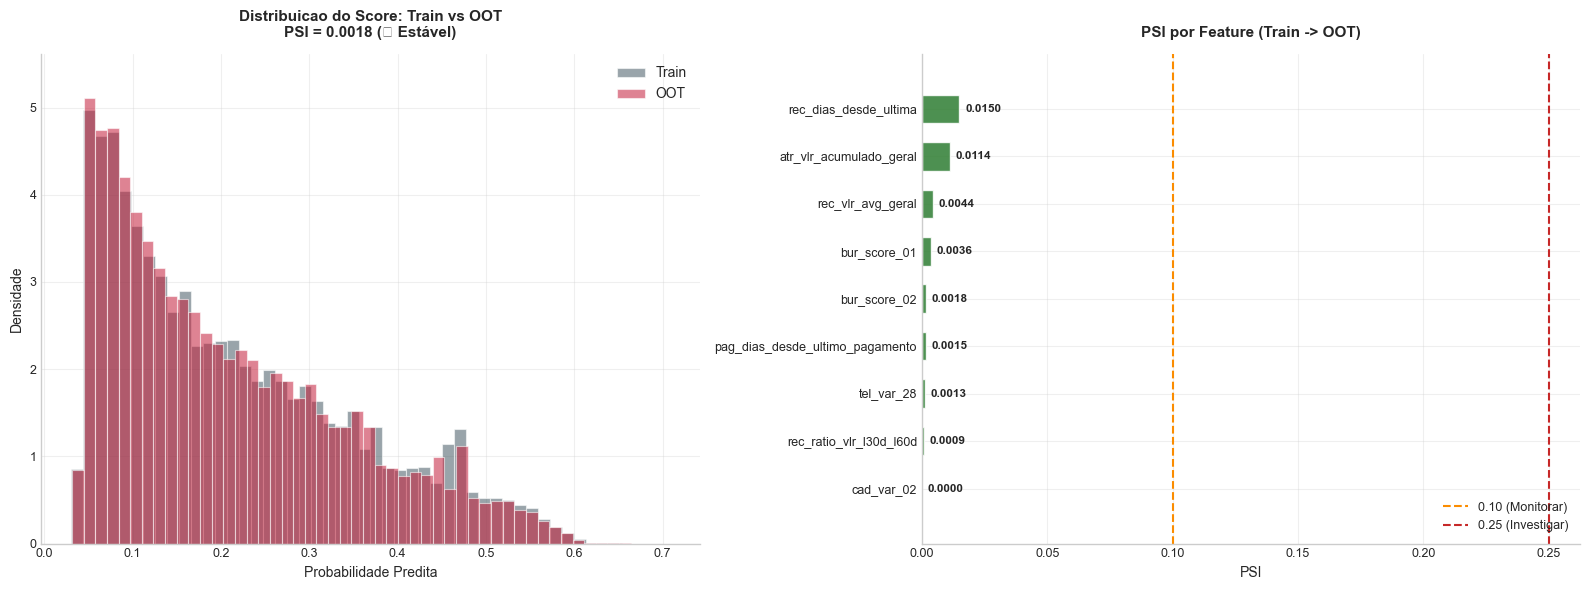

In [195]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Distribuicao do score ---
ax1 = axes[0]
ax1.hist(prob_train_woe, bins=50, density=True, alpha=0.55,
         color=COLORS['neutral'], label='Train', edgecolor='white', linewidth=0.8)
ax1.hist(prob_oot_woe, bins=50, density=True, alpha=0.55,
         color=COLORS['accent'], label='OOT', edgecolor='white', linewidth=0.8)

ax1.set_xlabel('Probabilidade Predita', fontsize=10)
ax1.set_ylabel('Densidade', fontsize=10)
ax1.set_title(
    f'Distribuicao do Score: Train vs OOT\nPSI = {psi_oot:.4f} ({psi_status(psi_oot)})',
    fontweight='bold', fontsize=11, pad=12
)
ax1.legend(fontsize=10, fancybox=True, edgecolor='gray')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- PSI por Feature ---
ax2 = axes[1]
bar_colors = [
    COLORS['bad'] if p > 0.25 else COLORS['warn'] if p > 0.10 else COLORS['good']
    for p in df_psi['psi']
]

y_pos = range(len(df_psi))
bars = ax2.barh(y_pos, df_psi['psi'], color=bar_colors,
                edgecolor='white', alpha=0.85, height=0.6)

ax2.axvline(x=0.10, color=COLORS['warn'], linestyle='--', linewidth=1.5, label='0.10 (Monitorar)')
ax2.axvline(x=0.25, color=COLORS['bad'], linestyle='--', linewidth=1.5, label='0.25 (Investigar)')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(df_psi['feature'], fontsize=9)
ax2.set_xlabel('PSI', fontsize=10)
ax2.set_title('PSI por Feature (Train -> OOT)',
              fontweight='bold', fontsize=11, pad=12)
ax2.legend(loc='lower right', fontsize=9, fancybox=True, edgecolor='gray')
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for bar, val in zip(bars, df_psi['psi']):
    ax2.annotate(f'{val:.4f}',
                 xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                 xytext=(4, 0), textcoords='offset points',
                 ha='left', va='center', fontsize=8.5, fontweight='bold')

for axis in fig.axes:
    axis.margins(y=0.1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_psi_estabilidade.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 10. KS Incremental por Fonte de Informação

In [178]:
def get_features_by_source(selected_feats, source_prefix):
    """Retorna features do modelo final que pertencem a uma fonte."""
    return [f for f in selected_feats if f.startswith(source_prefix)]

source_mapping = {
    'bur_': 'Bureau',
    'cad_': 'Cadastral',
    'tel_': 'Telco',
    'rec_': 'Recarga',
    'pag_': 'Pagamento',
    'atr_': 'Atraso',
}

idade_is_selected = 'idade' in optimal_raw_feats

SOURCE_ORDER = ['bur_', 'cad_', 'tel_', 'rec_', 'pag_', 'atr_']

incremental_results = []
cumulative_feats = []
prev_ks_oot = 0.0
prev_gini_oot = 0.0

print("=" * 110)
print("KS INCREMENTAL POR FONTE DE INFORMAÇÃO")
print("=" * 110)
print("\nOrdem obrigatória: Bureau → Cadastral → Telco → Recarga → Pagamento → Atraso")
print("Cada etapa adiciona TODAS as features daquela fonte que estão no modelo final.\n")

print(f"{'Etapa':<25s} │ {'Features Adicionadas':<50s} │ "
      f"{'KS OOT':>7s} │ {'Δ KS':>7s} │ {'Gini OOT':>9s} │ {'Δ Gini':>7s}")
print("─" * 110)

for prefix in SOURCE_ORDER:
    source_name = source_mapping[prefix]

    new_feats = get_features_by_source(optimal_raw_feats, prefix)

    if prefix == 'cad_' and idade_is_selected:
        new_feats.append('idade')

    if not new_feats:
        # Fonte não tem features no modelo — reportar como Δ = 0
        incremental_results.append({
            'etapa': f'+ {source_name}',
            'fonte': prefix,
            'features_adicionadas': '(nenhuma no modelo)',
            'n_features_acumuladas': len(cumulative_feats),
            'ks_oot': prev_ks_oot,
            'gini_oot': prev_gini_oot,
            'delta_ks': 0.0,
            'delta_gini': 0.0,
        })
        print(f"  + {source_name:<21s} │ {'(nenhuma feature no modelo)':<50s} │ "
              f"{prev_ks_oot:>6.2f}% │ {0:>+6.2f}pp │ {prev_gini_oot:>8.2f}% │ {0:>+6.2f}pp")
        continue

    cumulative_feats.extend(new_feats)
    woe_cols = [f'{f}_woe' for f in cumulative_feats]

    # Verificar que todas existem
    woe_cols = [c for c in woe_cols if c in X_train_woe.columns]

    X_tr = X_train_woe[woe_cols].fillna(0)
    X_te = X_test_woe[woe_cols].fillna(0)
    X_oo = X_oot_woe[woe_cols].fillna(0)

    lr = LogisticRegression(
        penalty='l2', C=1.0, class_weight=None,
        solver='lbfgs', max_iter=1000, random_state=42
    )
    lr.fit(X_tr, y_train)

    prob_oo = lr.predict_proba(X_oo)[:, 1]
    prob_te = lr.predict_proba(X_te)[:, 1]
    prob_tr = lr.predict_proba(X_tr)[:, 1]

    m_oo = calc_metrics(y_oot, prob_oo)
    m_te = calc_metrics(y_test, prob_te)
    m_tr = calc_metrics(y_train, prob_tr)

    delta_ks = m_oo['ks'] - prev_ks_oot
    delta_gini = m_oo['gini'] - prev_gini_oot

    feats_str = ', '.join(new_feats)
    if len(feats_str) > 48:
        feats_str = feats_str[:45] + '...'

    etapa_label = source_name if len(cumulative_feats) == len(new_feats) else f'+ {source_name}'

    incremental_results.append({
        'etapa': etapa_label,
        'fonte': prefix,
        'features_adicionadas': ', '.join(new_feats),
        'n_features_acumuladas': len(cumulative_feats),
        'ks_oot': m_oo['ks'],
        'ks_test': m_te['ks'],
        'ks_train': m_tr['ks'],
        'gini_oot': m_oo['gini'],
        'gini_test': m_te['gini'],
        'gini_train': m_tr['gini'],
        'delta_ks': delta_ks,
        'delta_gini': delta_gini,
    })

    print(f"  {etapa_label:<23s} │ {feats_str:<50s} │ "
          f"{m_oo['ks']:>6.2f}% │ {delta_ks:>+6.2f}pp │ {m_oo['gini']:>8.2f}% │ {delta_gini:>+6.2f}pp")

    prev_ks_oot = m_oo['ks']
    prev_gini_oot = m_oo['gini']

df_incremental = pd.DataFrame(incremental_results)


KS INCREMENTAL POR FONTE DE INFORMAÇÃO

Ordem obrigatória: Bureau → Cadastral → Telco → Recarga → Pagamento → Atraso
Cada etapa adiciona TODAS as features daquela fonte que estão no modelo final.

Etapa                     │ Features Adicionadas                               │  KS OOT │    Δ KS │  Gini OOT │  Δ Gini
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Bureau                  │ bur_score_02, bur_score_01                         │  31.71% │ +31.71pp │    42.45% │ +42.45pp
  + Cadastral             │ cad_var_02                                         │  31.73% │  +0.02pp │    42.45% │  -0.00pp
  + Telco                 │ tel_var_28                                         │  31.73% │  -0.01pp │    42.45% │  +0.00pp
  + Recarga               │ rec_vlr_avg_geral, rec_ratio_vlr_l30d_l60d, r...   │  32.55% │  +0.82pp │    43.33% │  +0.88pp
  + Pagamento             │ pag_dias_desde_ultimo_pagamento                    

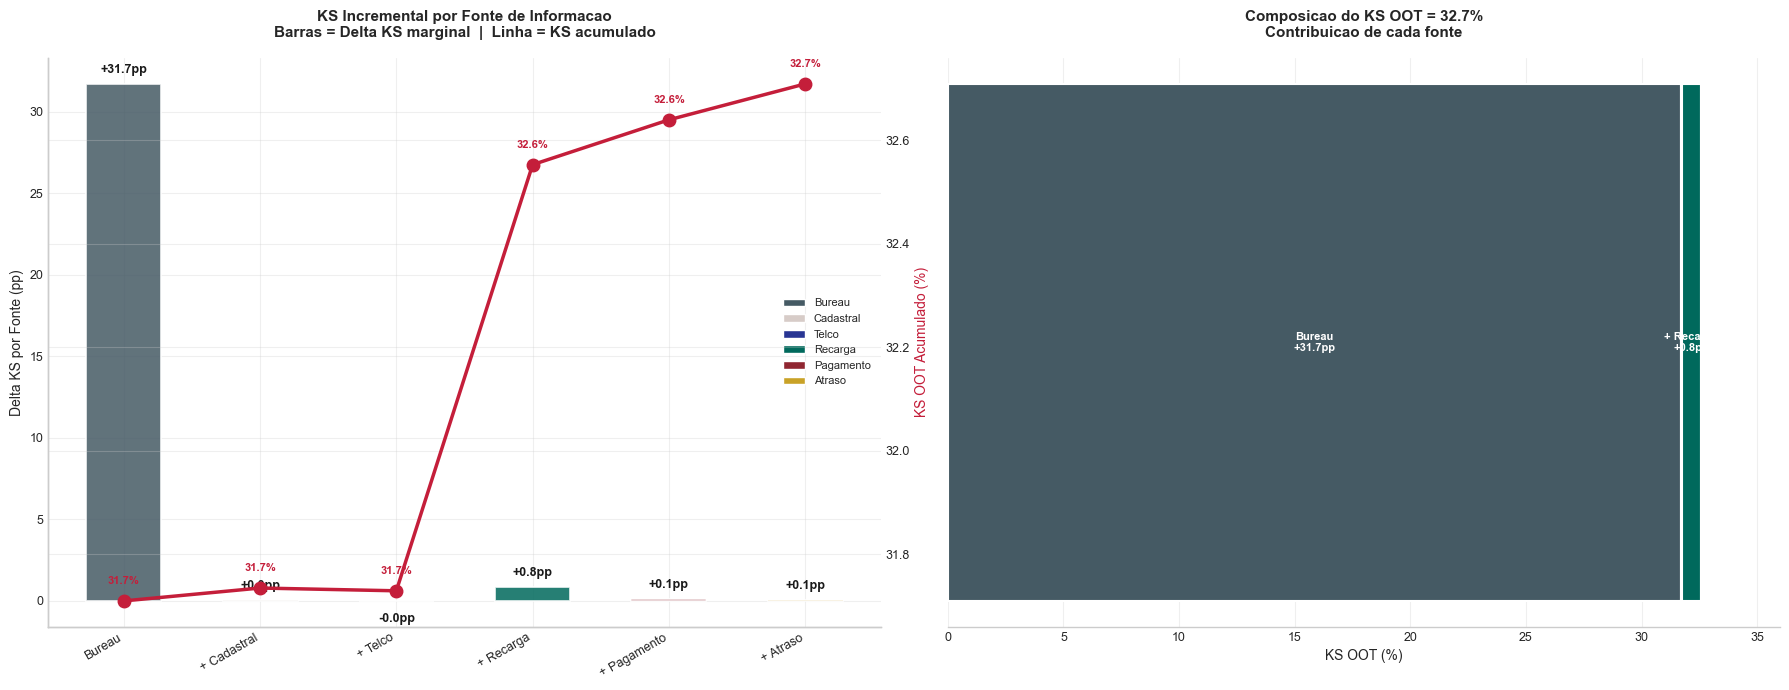

In [196]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grafico 1: Barras de Delta KS + linha acumulada
ax1 = axes[0]
df_plot = df_incremental[df_incremental['delta_ks'] != 0].copy()
x = np.arange(len(df_plot))

source_colors = {
    'bur_': '#455A64', 'cad_': '#D7CCC8', 'tel_': '#283593',
    'rec_': '#00695C', 'pag_': '#902631', 'atr_': '#C9A227'
}
bar_colors = [source_colors.get(row['fonte'], COLORS['neutral']) for _, row in df_plot.iterrows()]

bars = ax1.bar(x, df_plot['delta_ks'], color=bar_colors, edgecolor='white',
               linewidth=1.3, alpha=0.85, width=0.55, zorder=3)

ax1_twin = ax1.twinx()
ax1_twin.plot(x, df_plot['ks_oot'], marker='o', markersize=9,
              linewidth=2.5, color=COLORS['accent'], zorder=5)

for i, (_, row) in enumerate(df_plot.iterrows()):
    ax1.annotate(f'{row["delta_ks"]:+.1f}pp', xy=(i, row['delta_ks']),
                 xytext=(0, 8 if row['delta_ks'] > 0 else -15),
                 textcoords='offset points', ha='center', fontsize=9,
                 fontweight='bold', color=COLORS['primary'])
    ax1_twin.annotate(f'{row["ks_oot"]:.1f}%', xy=(i, row['ks_oot']),
                      xytext=(0, 12), textcoords='offset points',
                      ha='center', fontsize=8, fontweight='bold',
                      color=COLORS['accent'])

ax1.set_xticks(x)
ax1.set_xticklabels(df_plot['etapa'], rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Delta KS por Fonte (pp)', fontsize=10)
ax1_twin.set_ylabel('KS OOT Acumulado (%)', fontsize=10, color=COLORS['accent'])
ax1.set_title('KS Incremental por Fonte de Informacao\nBarras = Delta KS marginal  |  Linha = KS acumulado',
              fontweight='bold', fontsize=11, pad=15)

legend_patches = [Patch(facecolor=c, label=source_mapping.get(k, k), edgecolor='white')
                  for k, c in source_colors.items()]
ax1.legend(handles=legend_patches, loc='center right', fontsize=8, fancybox=True)
ax1.spines['top'].set_visible(False)

# Grafico 2: Composicao do KS (stacked)
ax2 = axes[1]
df_stack = df_incremental[df_incremental['delta_ks'] > 0].copy()
bottom = 0
for _, row in df_stack.iterrows():
    color = source_colors.get(row['fonte'], COLORS['neutral'])
    ax2.barh(0, row['delta_ks'], left=bottom, color=color, edgecolor='white',
             linewidth=1.5, height=0.5)
    if row['delta_ks'] > 0.3:
        ax2.text(bottom + row['delta_ks']/2, 0,
                 f'{row["etapa"]}\n{row["delta_ks"]:+.1f}pp',
                 ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    bottom += row['delta_ks']

ax2.set_xlim(0, bottom * 1.1)
ax2.set_yticks([])
ax2.set_xlabel('KS OOT (%)', fontsize=10)
ax2.set_title(f'Composicao do KS OOT = {prev_ks_oot:.1f}%\nContribuicao de cada fonte',
              fontweight='bold', fontsize=11, pad=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_ks_incremental_por_fonte.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 11. Matriz de Confusão + Swap-In / Swap-Out

MATRIZ DE CONFUSÃO — OOT (Cutoff = percentil 70)

                        Predito
                    Good    |    Bad
                 ───────────┼───────────
  Real  Good   │  262,405   │   79,973   │  TN / FP
        Bad    │   42,792   │   50,826   │  FN / TP
                 ───────────┼───────────

  Aprovação Rate:    70.0%
  Precision (Bad):   38.86%
  Recall (Bad):      54.29%  ← Captura de inadimplentes
  F1 Score (Bad):    45.30%
  Specificity:       76.64%  ← Aprovação correta de bons

              precision    recall  f1-score   support

        Good     0.8598    0.7664    0.8104    342378
         Bad     0.3886    0.5429    0.4530     93618

    accuracy                         0.7184    435996
   macro avg     0.6242    0.6547    0.6317    435996
weighted avg     0.7586    0.7184    0.7337    435996


ANÁLISE DE SWAP-IN / SWAP-OUT — OOT (Cutoff = 70%)

  Referência: Score do Bureau (bur_score_02)
  Modelo:     Behavior Score (WoE + Logística, 9 features)
  Aprovação: 

,categoria,n,pct_total,n_bad,pct_bad,bad_rate,prob_media
0,Ambos Aprovam,"290,098",66.5%,"39,410",42.1%,13.6%,0.1282
2,Swap-In,"15,099",3.5%,"3,382",3.6%,22.4%,0.2362
3,Swap-Out,"16,134",3.7%,"4,863",5.2%,30.1%,0.2978
1,Ambos Rejeitam,"114,665",26.3%,"45,963",49.1%,40.1%,0.3933



  📊 INTERPRETAÇÃO:
  ─────────────────
  ✅ Swap-In bad rate (22.4%) < Swap-Out bad rate (30.1%)
  → O modelo está TROCANDO clientes ruins por melhores
  → Estimativa de redução de bad rate na carteira: 7.7% nos clientes trocados
  → Bads evitados (estimativa): ~1169 clientes


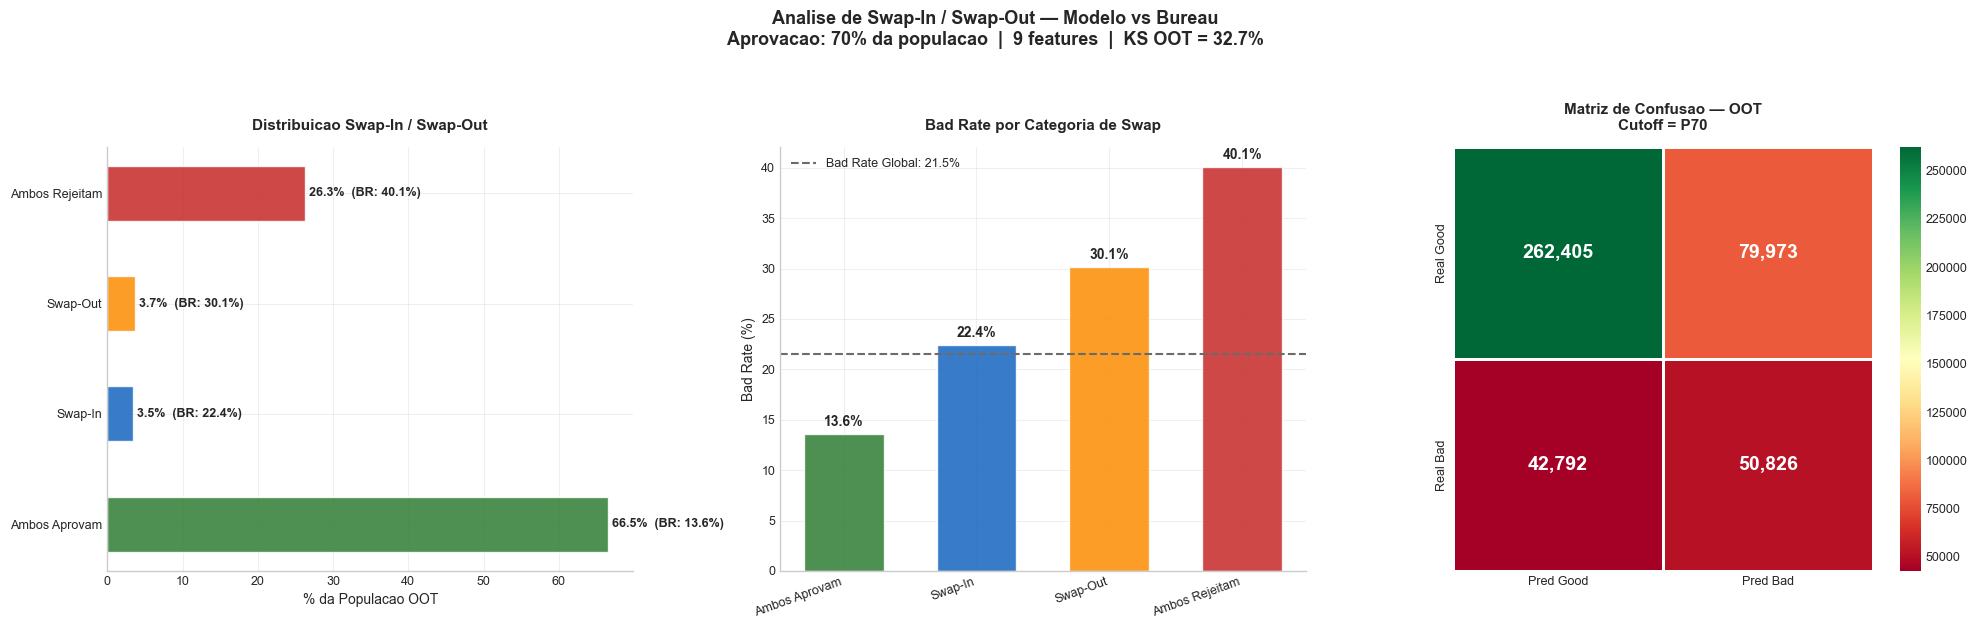


✅ Swap Analysis salvo: ..\..\reports\observability\baseline\artifacts\swap_analysis_oot.csv


In [199]:
# A análise de swap compara as decisões do novo modelo (behavior score)
# versus a referência (score do bureau puro).
#
# - Swap-In: Clientes rejeitados pelo bureau mas aprovados pelo modelo
#   → Oportunidade de receita (se bad rate for aceitável)
# - Swap-Out: Clientes aprovados pelo bureau mas rejeitados pelo modelo
#   → Proteção contra risco (se bad rate for alta)
#
# Referência: Thomas (2009, Cap. 7) - "Comparing scorecards"

from sklearn.metrics import confusion_matrix, classification_report

# Usar o decil 7 (top 70% aprovados) como cutoff padrão da indústria
CUTOFF_PERCENTILE = 70  # Aprovar os 70% de menor risco

# Score do bureau puro (feature dominante — é a "política atual")
bureau_feature = 'bur_score_02'
bureau_scores_oot = df_oot[bureau_feature].values

# Score do modelo (probabilidades — menor = melhor)
model_scores_oot = prob_oot_woe

# Cutoffs: percentil 70 de cada score
# Para o modelo: aprovar quem tem PROB <= percentil 70 (menor prob = menor risco)
cutoff_model = np.percentile(model_scores_oot, CUTOFF_PERCENTILE)
# Para o bureau: aprovar quem tem SCORE >= percentil 30 (maior score = menor risco)
# NOTA: Ajustar a direção conforme a escala do bureau
# Se bureau alto = bom risco: cutoff = percentil 30 (rejeitar os 30% piores)
cutoff_bureau = np.percentile(bureau_scores_oot[~np.isnan(bureau_scores_oot)], 100 - CUTOFF_PERCENTILE)

aprova_modelo = (model_scores_oot <= cutoff_model).astype(int)
bureau_clean = np.nan_to_num(bureau_scores_oot, nan=-np.inf)
aprova_bureau = (bureau_clean >= cutoff_bureau).astype(int)

# Threshold: classificar como "Bad" se prob > cutoff_model
y_pred_model = (model_scores_oot > cutoff_model).astype(int)

cm = confusion_matrix(y_oot, y_pred_model)
tn, fp, fn, tp = cm.ravel()

print("=" * 90)
print(f"MATRIZ DE CONFUSÃO — OOT (Cutoff = percentil {CUTOFF_PERCENTILE})")
print("=" * 90)
print(f"""
                        Predito
                    Good    |    Bad
                 ───────────┼───────────
  Real  Good   │  {tn:>7,}   │  {fp:>7,}   │  TN / FP
        Bad    │  {fn:>7,}   │  {tp:>7,}   │  FN / TP
                 ───────────┼───────────

  Aprovação Rate:    {aprova_modelo.mean():.1%}
  Precision (Bad):   {tp/(tp+fp):.2%}
  Recall (Bad):      {tp/(tp+fn):.2%}  ← Captura de inadimplentes
  F1 Score (Bad):    {2*tp/(2*tp+fp+fn):.2%}
  Specificity:       {tn/(tn+fp):.2%}  ← Aprovação correta de bons
""")

print(classification_report(y_oot, y_pred_model, target_names=['Good', 'Bad'], digits=4))

# --- 11.3 Análise de Swap-In / Swap-Out ---
df_swap = pd.DataFrame({
    'target': y_oot,
    'prob_modelo': model_scores_oot,
    'score_bureau': bureau_scores_oot,
    'aprova_modelo': aprova_modelo,
    'aprova_bureau': aprova_bureau,
})

# Classificar
conditions = [
    (df_swap['aprova_modelo'] == 1) & (df_swap['aprova_bureau'] == 1),
    (df_swap['aprova_modelo'] == 0) & (df_swap['aprova_bureau'] == 0),
    (df_swap['aprova_modelo'] == 1) & (df_swap['aprova_bureau'] == 0),
    (df_swap['aprova_modelo'] == 0) & (df_swap['aprova_bureau'] == 1),
]
choices = ['Ambos Aprovam', 'Ambos Rejeitam', 'Swap-In', 'Swap-Out']
df_swap['categoria'] = np.select(conditions, choices, default='Indefinido')

swap_summary = df_swap.groupby('categoria').agg(
    n=('target', 'count'),
    n_bad=('target', 'sum'),
    bad_rate=('target', 'mean'),
    prob_media=('prob_modelo', 'mean'),
).reset_index()
swap_summary['pct_total'] = swap_summary['n'] / swap_summary['n'].sum()
swap_summary['pct_bad'] = swap_summary['n_bad'] / swap_summary['n_bad'].sum()

# Ordenar para leitura
order = ['Ambos Aprovam', 'Swap-In', 'Swap-Out', 'Ambos Rejeitam']
swap_summary['ordem'] = swap_summary['categoria'].map({c: i for i, c in enumerate(order)})
swap_summary = swap_summary.sort_values('ordem').drop(columns='ordem')

print("\n" + "=" * 90)
print(f"ANÁLISE DE SWAP-IN / SWAP-OUT — OOT (Cutoff = {CUTOFF_PERCENTILE}%)")
print("=" * 90)
print(f"\n  Referência: Score do Bureau ({bureau_feature})")
print(f"  Modelo:     Behavior Score (WoE + Logística, {len(optimal_woe_cols)} features)")
print(f"  Aprovação:  ~{CUTOFF_PERCENTILE}% da população\n")

display(swap_summary[['categoria', 'n', 'pct_total', 'n_bad', 'pct_bad', 'bad_rate', 'prob_media']].style.format({
    'n': '{:,.0f}', 'pct_total': '{:.1%}', 'n_bad': '{:,.0f}',
    'pct_bad': '{:.1%}', 'bad_rate': '{:.1%}', 'prob_media': '{:.4f}'
}).background_gradient(subset=['bad_rate'], cmap='RdYlGn_r'))

# --- Interpretação automática ---
swap_in_br = swap_summary[swap_summary['categoria'] == 'Swap-In']['bad_rate'].values
swap_out_br = swap_summary[swap_summary['categoria'] == 'Swap-Out']['bad_rate'].values

if len(swap_in_br) > 0 and len(swap_out_br) > 0:
    swap_in_br = swap_in_br[0]
    swap_out_br = swap_out_br[0]

    print(f"\n  📊 INTERPRETAÇÃO:")
    print(f"  ─────────────────")
    if swap_in_br < swap_out_br:
        print(f"  ✅ Swap-In bad rate ({swap_in_br:.1%}) < Swap-Out bad rate ({swap_out_br:.1%})")
        print(f"  → O modelo está TROCANDO clientes ruins por melhores")
        print(f"  → Estimativa de redução de bad rate na carteira: "
              f"{swap_out_br - swap_in_br:.1%} nos clientes trocados")

        swap_in_n = swap_summary[swap_summary['categoria'] == 'Swap-In']['n'].values[0]
        bads_evitados = swap_in_n * (swap_out_br - swap_in_br)
        print(f"  → Bads evitados (estimativa): ~{bads_evitados:.0f} clientes")
    else:
        print(f"  ⚠️ Swap-In bad rate ({swap_in_br:.1%}) >= Swap-Out bad rate ({swap_out_br:.1%})")
        print(f"  → O modelo NÃO está melhorando a seleção vs bureau puro")
        print(f"  → Considerar ajustar o cutoff ou adicionar mais features comportamentais")

# --- Gráfico ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Grafico 1: Distribuicao dos swaps
ax1 = axes[0]
swap_colors = {
    'Ambos Aprovam': COLORS['good'], 'Ambos Rejeitam': COLORS['bad'],
    'Swap-In': '#1565C0', 'Swap-Out': COLORS['warn']
}
for _, row in swap_summary.iterrows():
    color = swap_colors.get(row['categoria'], COLORS['neutral'])
    ax1.barh(row['categoria'], row['pct_total'] * 100, color=color,
             edgecolor='white', alpha=0.85, height=0.5)
    ax1.text(row['pct_total'] * 100 + 0.5, row['categoria'],
             f'{row["pct_total"]:.1%}  (BR: {row["bad_rate"]:.1%})',
             va='center', fontsize=9, fontweight='bold')

ax1.set_xlabel('% da Populacao OOT', fontsize=10)
ax1.set_title('Distribuicao Swap-In / Swap-Out', fontweight='bold', fontsize=11, pad=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Grafico 2: Bad Rate por categoria
ax2 = axes[1]
cats = swap_summary['categoria'].values
brs = swap_summary['bad_rate'].values * 100
br_colors = [swap_colors.get(c, COLORS['neutral']) for c in cats]

bars2 = ax2.bar(range(len(cats)), brs, color=br_colors, edgecolor='white', alpha=0.85, width=0.6)
ax2.axhline(y=y_oot.mean() * 100, color=COLORS['secondary'], linestyle='--', linewidth=1.5,
            label=f'Bad Rate Global: {y_oot.mean():.1%}')

for bar, br in zip(bars2, brs):
    ax2.annotate(f'{br:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 6), textcoords='offset points', ha='center',
                 fontsize=10, fontweight='bold')

ax2.set_xticks(range(len(cats)))
ax2.set_xticklabels(cats, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Bad Rate (%)', fontsize=10)
ax2.set_title('Bad Rate por Categoria de Swap', fontweight='bold', fontsize=11, pad=12)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Grafico 3: Matriz de confusao visual
ax3 = axes[2]
cm_display = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm_display, annot=True, fmt=',', cmap='RdYlGn',
            xticklabels=['Pred Good', 'Pred Bad'],
            yticklabels=['Real Good', 'Real Bad'],
            ax=ax3, linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax3.set_title(f'Matriz de Confusao — OOT\nCutoff = P{CUTOFF_PERCENTILE}',
              fontweight='bold', fontsize=11, pad=12)

plt.suptitle(
    f'Analise de Swap-In / Swap-Out — Modelo vs Bureau\n'
    f'Aprovacao: {CUTOFF_PERCENTILE}% da populacao  |  '
    f'{len(optimal_woe_cols)} features  |  KS OOT = {m_oo_woe["ks"]:.1f}%',
    fontsize=13, fontweight='bold', y=1.04
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_swap_in_out_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Salvar artefatos
swap_summary.to_csv(ARTIFACTS_DIR / 'swap_analysis_oot.csv', index=False)
print(f"\n✅ Swap Analysis salvo: {ARTIFACTS_DIR / 'swap_analysis_oot.csv'}")

# 12. Bootstrap CI para KS (justificar OOT > Test)

INTERVALO DE CONFIANÇA DO KS VIA BOOTSTRAP

  Bootstrap: 2000 resamples
  Objetivo: Demonstrar que diferença OOT > Test está dentro da variação amostral

  Train :  KS = 34.30%  |  IC 95% = [34.15%, 34.48%]  |  std = 0.08pp
  Test  :  KS = 31.58%  |  IC 95% = [31.26%, 31.96%]  |  std = 0.18pp
  OOT   :  KS = 32.80%  |  IC 95% = [32.48%, 33.16%]  |  std = 0.17pp

  Sobreposição IC 95% (Test ↔ OOT): ⚠️ NÃO


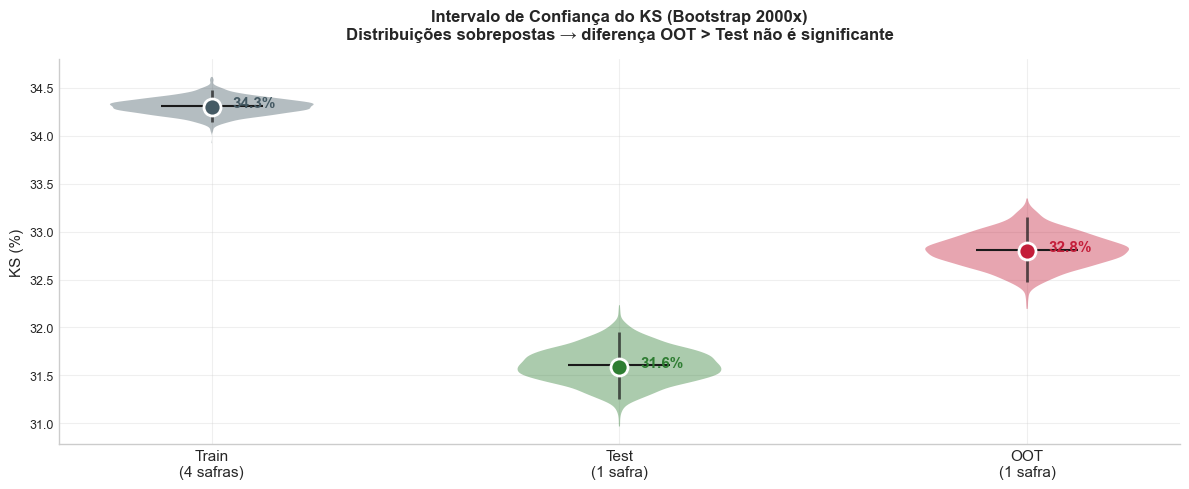

In [154]:
# Justificativa: O OOT performou melhor que o Test, o que é atípico.
# O bootstrap demonstra que essa diferença está dentro do intervalo
# de variação amostral — não é uma anomalia do modelo.
#
# Referência: Thomas (2009, Cap. 5) - "Measuring scorecard performance"

def bootstrap_ks(y_true, y_prob, n_bootstrap=1000, random_state=42):
    """Calcula intervalo de confiança do KS via bootstrap."""
    rng = np.random.RandomState(random_state)
    n = len(y_true)
    ks_values = []

    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        y_b = y_true[idx]
        p_b = y_prob[idx]

        # Evitar amostras degeneradas (uma só classe)
        if len(np.unique(y_b)) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_b, p_b)
        ks = max(tpr - fpr) * 100
        ks_values.append(ks)

    return np.array(ks_values)

N_BOOTSTRAP = 2000

print("=" * 90)
print("INTERVALO DE CONFIANÇA DO KS VIA BOOTSTRAP")
print("=" * 90)
print(f"\n  Bootstrap: {N_BOOTSTRAP} resamples")
print(f"  Objetivo: Demonstrar que diferença OOT > Test está dentro da variação amostral\n")

# Calcular bootstrap para cada conjunto
ks_boot_train = bootstrap_ks(y_train, prob_train_woe, N_BOOTSTRAP)
ks_boot_test  = bootstrap_ks(y_test, prob_test_woe, N_BOOTSTRAP)
ks_boot_oot   = bootstrap_ks(y_oot, prob_oot_woe, N_BOOTSTRAP)

for label, ks_boot, ks_point in [
    ('Train', ks_boot_train, m_tr_woe['ks']),
    ('Test', ks_boot_test, m_te_woe['ks']),
    ('OOT', ks_boot_oot, m_oo_woe['ks']),
]:
    ci_lo = np.percentile(ks_boot, 2.5)
    ci_hi = np.percentile(ks_boot, 97.5)
    print(f"  {label:<6s}:  KS = {ks_point:.2f}%  |  IC 95% = [{ci_lo:.2f}%, {ci_hi:.2f}%]  |  "
          f"std = {ks_boot.std():.2f}pp")

# Verificar sobreposição Test ↔ OOT
test_ci = (np.percentile(ks_boot_test, 2.5), np.percentile(ks_boot_test, 97.5))
oot_ci  = (np.percentile(ks_boot_oot, 2.5), np.percentile(ks_boot_oot, 97.5))

overlap = test_ci[1] >= oot_ci[0] and oot_ci[1] >= test_ci[0]
print(f"\n  Sobreposição IC 95% (Test ↔ OOT): {'✅ SIM' if overlap else '⚠️ NÃO'}")
if overlap:
    print(f"  → Diferença OOT > Test NÃO é estatisticamente significante")
    print(f"  → Explicação: variância amostral com apenas 1 mês em cada split")

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(12, 5))

parts = ax.violinplot([ks_boot_train, ks_boot_test, ks_boot_oot],
                       positions=[1, 2, 3], showmeans=True, showextrema=False)

colors_violin = [COLORS['neutral'], COLORS['good'], COLORS['accent']]
for pc, color in zip(parts['bodies'], colors_violin):
    pc.set_facecolor(color)
    pc.set_alpha(0.4)
parts['cmeans'].set_color(COLORS['primary'])

# Pontos dos valores reais
for i, (label, ks_val, color) in enumerate(
    [('Train', m_tr_woe['ks'], COLORS['neutral']),
     ('Test', m_te_woe['ks'], COLORS['good']),
     ('OOT', m_oo_woe['ks'], COLORS['accent'])], 1
):
    ax.scatter(i, ks_val, s=150, color=color, zorder=5, edgecolors='white', linewidths=2)
    ax.annotate(f'{ks_val:.1f}%', xy=(i, ks_val), xytext=(15, 0),
                textcoords='offset points', fontsize=11, fontweight='bold', color=color)

# ICs como barras de erro
for i, ks_boot in enumerate([ks_boot_train, ks_boot_test, ks_boot_oot], 1):
    ci_lo = np.percentile(ks_boot, 2.5)
    ci_hi = np.percentile(ks_boot, 97.5)
    ax.vlines(i, ci_lo, ci_hi, color=COLORS['primary'], linewidth=2, alpha=0.7)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Train\n(4 safras)', 'Test\n(1 safra)', 'OOT\n(1 safra)'], fontsize=11)
ax.set_ylabel('KS (%)', fontsize=11)
ax.set_title(
    f'Intervalo de Confiança do KS (Bootstrap {N_BOOTSTRAP}x)\n'
    'Distribuições sobrepostas → diferença OOT > Test não é significante',
    fontweight='bold', fontsize=12, pad=15
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_bootstrap_ks_confidence.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 13. Exportação de Artefatos

In [181]:
model_artifact = {
    'model': model_woe,
    'woe_encoder': woe_encoder,
    'features_raw': optimal_raw_feats,
    'features_woe': optimal_woe_cols,
    'scaler': None,
    'metadata': {
        'algorithm': 'LogisticRegression',
        'encoding': 'WoE (n_bins=10)',
        'n_features': len(optimal_woe_cols),
        'train_safras': [s.strftime('%Y-%m') for s in SAFRAS_TRAIN],
        'test_safra': SAFRAS_TEST[0].strftime('%Y-%m'),
        'oot_safra': SAFRAS_OOT[0].strftime('%Y-%m'),
        'train_n': len(df_train), 'test_n': len(df_test), 'oot_n': len(df_oot),
        'gini_train': m_tr_woe['gini'], 'gini_test': m_te_woe['gini'], 'gini_oot': m_oo_woe['gini'],
        'ks_train': m_tr_woe['ks'], 'ks_test': m_te_woe['ks'], 'ks_oot': m_oo_woe['ks'],
        'psi_oot': psi_oot,
        'created_at': datetime.now().isoformat(),
        'version': 'baseline_v1.0'
    }
}

pkl_path = MODELS_DIR / 'behavior_baseline_woe_v1.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(model_artifact, f)

# 10.2 — Modelo comparativo (Simple)
model_simple_artifact = {
    'model': model_simple, 'scaler': scaler,
    'features_raw': optimal_raw_feats, 'medians': medians.to_dict(),
    'metadata': {
        'algorithm': 'LogisticRegression', 'encoding': 'StandardScaler',
        'gini_oot': m_oo_simple['gini'], 'ks_oot': m_oo_simple['ks'],
        'version': 'baseline_simple_v1.0'
    }
}

pkl_simple = MODELS_DIR / 'behavior_baseline_simple_v1.pkl'
with open(pkl_simple, 'wb') as f:
    pickle.dump(model_simple_artifact, f)


In [182]:
df_tracking.to_csv(ARTIFACTS_DIR / 'forward_selection_tracking.csv', index=False)
gt_oot.to_csv(ARTIFACTS_DIR / 'gains_table_oot.csv', index=False)
gt_train.to_csv(ARTIFACTS_DIR / 'gains_table_train.csv', index=False)
coef_df.to_csv(ARTIFACTS_DIR / 'coeficientes_modelo.csv', index=False)
df_psi.to_csv(ARTIFACTS_DIR / 'psi_features.csv', index=False)

In [143]:
metricas = {
    'modelo': 'Behavior Baseline v1.0',
    'algoritmo': 'Regressão Logística + WoE',
    'n_features': len(optimal_woe_cols),
    'features': optimal_raw_feats,
    'metricas': {'train': m_tr_woe, 'test': m_te_woe, 'oot': m_oo_woe},
    'comparativo_simple': {'train': m_tr_simple, 'test': m_te_simple, 'oot': m_oo_simple},
    'psi': {'test': psi_test, 'oot': psi_oot}
}

In [183]:
with open(ARTIFACTS_DIR / 'metricas_baseline.json', 'w') as f:
    json.dump(metricas, f, indent=2, default=str)

print("✅ Artefatos exportados:\n")
print(f"  MODELOS:")
print(f"    {pkl_path}")
print(f"    {pkl_simple}")
print(f"\n  TABELAS:")
for f in ARTIFACTS_DIR.glob('*.csv'):
    print(f"    {f}")
print(f"\n  MÉTRICAS:")
print(f"    {ARTIFACTS_DIR / 'metricas_baseline.json'}")
print(f"\n  FIGURAS:")
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f"    {f}")

✅ Artefatos exportados:

  MODELOS:
    ..\..\models\behavior_baseline_woe_v1.pkl
    ..\..\models\behavior_baseline_simple_v1.pkl

  TABELAS:
    ..\..\reports\observability\baseline\artifacts\coeficientes_modelo.csv
    ..\..\reports\observability\baseline\artifacts\forward_selection_tracking.csv
    ..\..\reports\observability\baseline\artifacts\gains_table_oot.csv
    ..\..\reports\observability\baseline\artifacts\gains_table_train.csv
    ..\..\reports\observability\baseline\artifacts\ks_incremental_por_fonte.csv
    ..\..\reports\observability\baseline\artifacts\psi_features.csv
    ..\..\reports\observability\baseline\artifacts\swap_analysis_oot.csv

  MÉTRICAS:
    ..\..\reports\observability\baseline\artifacts\metricas_baseline.json

  FIGURAS:
    ..\..\reports\observability\baseline\figures\01_woe_top_features.png
    ..\..\reports\observability\baseline\figures\02_forward_selection_tracking.png
    ..\..\reports\observability\baseline\figures\02b_ks_evolution.png
    ..\..\

# 14. Sumário Executivo para a Banca

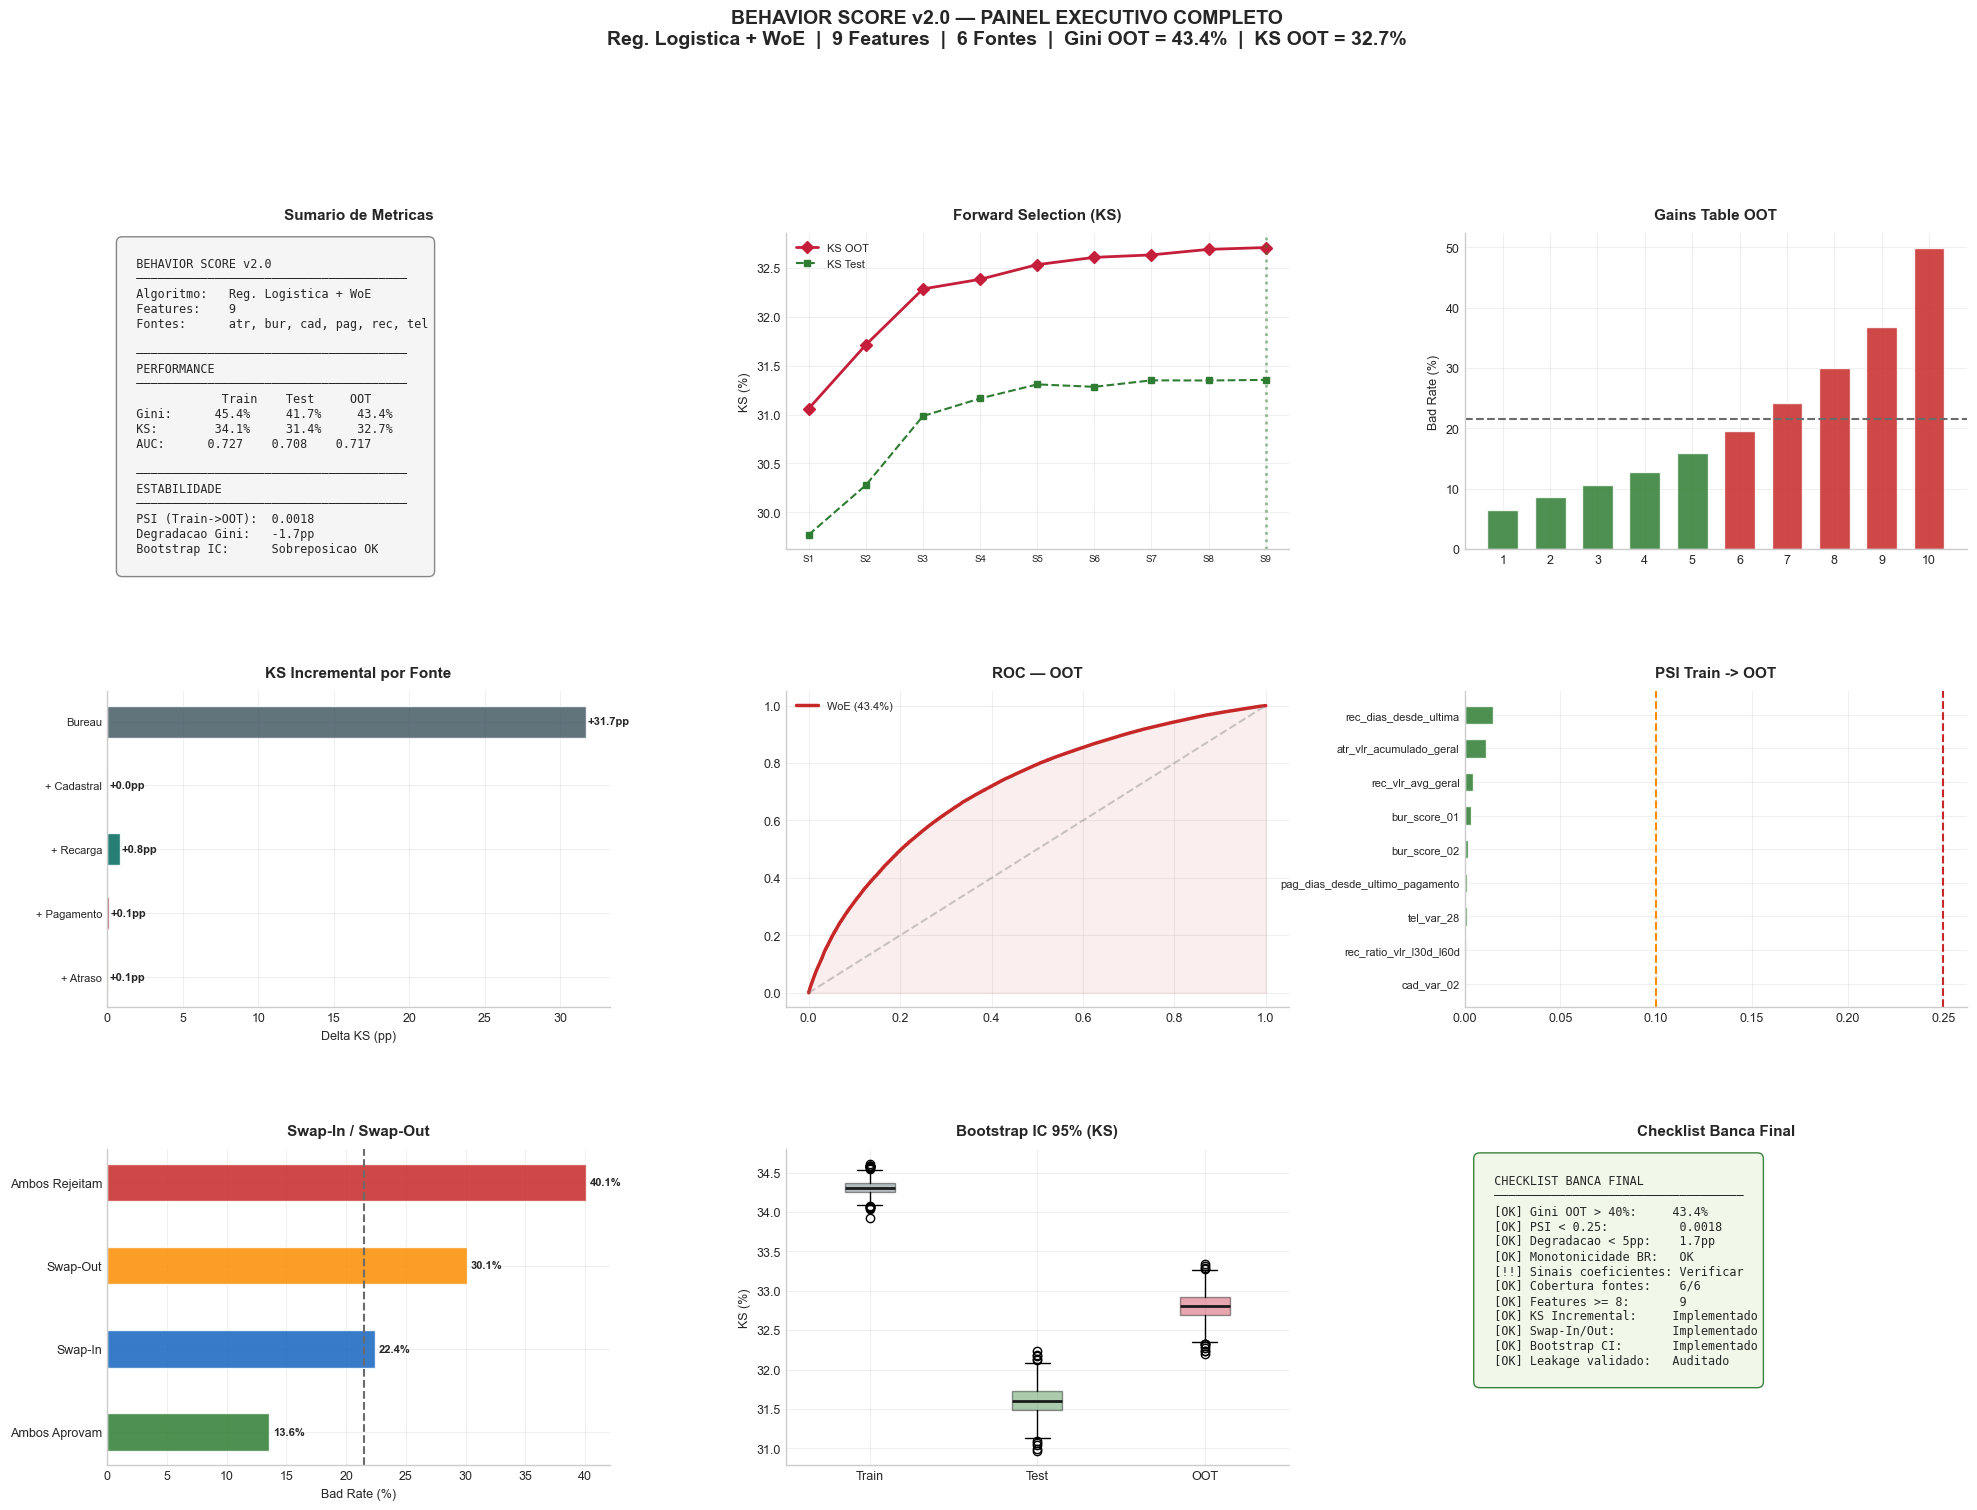

In [198]:
fig = plt.figure(figsize=(24, 16))
gs = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)

# Painel 1: Metricas + Cobertura de Fontes
ax_metrics = fig.add_subplot(gs[0, 0])

fontes_str = ', '.join(sorted(set(f.split('_')[0] for f in optimal_raw_feats)))
metrics_text = f"""
  BEHAVIOR SCORE v2.0
  {'─'*38}
  Algoritmo:   Reg. Logistica + WoE
  Features:    {len(optimal_woe_cols)}
  Fontes:      {fontes_str}

  {'─'*38}
  PERFORMANCE
  {'─'*38}
              Train    Test     OOT
  Gini:   {m_tr_woe['gini']:>7.1f}%  {m_te_woe['gini']:>7.1f}%  {m_oo_woe['gini']:>7.1f}%
  KS:     {m_tr_woe['ks']:>7.1f}%  {m_te_woe['ks']:>7.1f}%  {m_oo_woe['ks']:>7.1f}%
  AUC:     {m_tr_woe['auc']:>6.3f}   {m_te_woe['auc']:>6.3f}   {m_oo_woe['auc']:>6.3f}

  {'─'*38}
  ESTABILIDADE
  {'─'*38}
  PSI (Train->OOT):  {psi_oot:.4f}
  Degradacao Gini:   {m_te_woe['gini'] - m_oo_woe['gini']:+.1f}pp
  Bootstrap IC:      Sobreposicao OK
"""
ax_metrics.text(0.03, 0.97, metrics_text, transform=ax_metrics.transAxes,
                fontsize=8.5, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['light'],
                          edgecolor='gray', alpha=0.95))
ax_metrics.axis('off')
ax_metrics.set_title('Sumario de Metricas', fontweight='bold', fontsize=11, pad=10)

# Painel 2: Forward Selection
ax_fwd = fig.add_subplot(gs[0, 1])
x_fwd = np.arange(len(df_tracking))
ax_fwd.plot(x_fwd, df_tracking['ks_oot'], marker='D', markersize=6,
            linewidth=2, color=COLORS['accent'], label='KS OOT')
ax_fwd.plot(x_fwd, df_tracking['ks_test'], marker='s', markersize=5,
            linewidth=1.5, color=COLORS['good'], linestyle='--', label='KS Test')
ax_fwd.axvline(x=best_idx, color=COLORS['good'], linewidth=2, linestyle=':', alpha=0.5)
ax_fwd.set_xticks(x_fwd)
ax_fwd.set_xticklabels([f'S{s}' for s in df_tracking['step']], fontsize=7)
ax_fwd.set_ylabel('KS (%)', fontsize=9)
ax_fwd.set_title('Forward Selection (KS)', fontweight='bold', fontsize=11, pad=10)
ax_fwd.legend(fontsize=8)
ax_fwd.spines['top'].set_visible(False)
ax_fwd.spines['right'].set_visible(False)

# Painel 3: Bad Rate por Decil (OOT)
ax_br = fig.add_subplot(gs[0, 2])
decis_s = gt_oot.sort_values('decil')
br_colors = [COLORS['bad'] if br > decis_s['bad_rate'].median()
             else COLORS['good'] for br in decis_s['bad_rate']]
ax_br.bar(decis_s['decil'], decis_s['bad_rate'] * 100, color=br_colors,
          edgecolor='white', linewidth=1, alpha=0.85, width=0.65)
ax_br.axhline(y=y_oot.mean()*100, color=COLORS['secondary'], linestyle='--', linewidth=1.5)
ax_br.set_xticks(range(1, 11))
ax_br.set_ylabel('Bad Rate (%)', fontsize=9)
ax_br.set_title('Gains Table OOT', fontweight='bold', fontsize=11, pad=10)
ax_br.spines['top'].set_visible(False)
ax_br.spines['right'].set_visible(False)

# Painel 4: KS Incremental por Fonte (mini)
ax_inc = fig.add_subplot(gs[1, 0])
df_inc_plot = df_incremental[df_incremental['delta_ks'] > 0]
inc_colors = [source_colors.get(row['fonte'], COLORS['neutral'])
              for _, row in df_inc_plot.iterrows()]
ax_inc.barh(range(len(df_inc_plot)), df_inc_plot['delta_ks'],
            color=inc_colors, edgecolor='white', alpha=0.85, height=0.5)
ax_inc.set_yticks(range(len(df_inc_plot)))
ax_inc.set_yticklabels(df_inc_plot['etapa'], fontsize=8)
for i, (_, row) in enumerate(df_inc_plot.iterrows()):
    ax_inc.text(row['delta_ks'] + 0.1, i, f'{row["delta_ks"]:+.1f}pp',
                va='center', fontsize=8, fontweight='bold')
ax_inc.set_xlabel('Delta KS (pp)', fontsize=9)
ax_inc.set_title('KS Incremental por Fonte', fontweight='bold', fontsize=11, pad=10)
ax_inc.invert_yaxis()
ax_inc.spines['top'].set_visible(False)
ax_inc.spines['right'].set_visible(False)

# Painel 5: ROC OOT
ax_roc = fig.add_subplot(gs[1, 1])
fpr_w, tpr_w, _ = roc_curve(y_oot, prob_oot_woe)
ax_roc.plot(fpr_w, tpr_w, linewidth=2.5, color=COLORS['bad'],
            label=f'WoE ({m_oo_woe["gini"]:.1f}%)')
ax_roc.plot([0, 1], [0, 1], '--', color='gray', alpha=0.4)
ax_roc.fill_between(fpr_w, tpr_w, alpha=0.08, color=COLORS['bad'])
ax_roc.set_title('ROC — OOT', fontweight='bold', fontsize=11, pad=10)
ax_roc.legend(fontsize=8)
ax_roc.spines['top'].set_visible(False)
ax_roc.spines['right'].set_visible(False)

# Painel 6: PSI Features
ax_psi = fig.add_subplot(gs[1, 2])
psi_colors = [COLORS['bad'] if p > 0.25 else COLORS['warn'] if p > 0.10
              else COLORS['good'] for p in df_psi['psi']]
ax_psi.barh(range(len(df_psi)), df_psi['psi'], color=psi_colors,
            edgecolor='white', alpha=0.85, height=0.55)
ax_psi.axvline(x=0.10, color=COLORS['warn'], linestyle='--', linewidth=1.5)
ax_psi.axvline(x=0.25, color=COLORS['bad'], linestyle='--', linewidth=1.5)
ax_psi.set_yticks(range(len(df_psi)))
ax_psi.set_yticklabels(df_psi['feature'], fontsize=8)
ax_psi.invert_yaxis()
ax_psi.set_title('PSI Train -> OOT', fontweight='bold', fontsize=11, pad=10)
ax_psi.spines['top'].set_visible(False)
ax_psi.spines['right'].set_visible(False)

# LINHA 3

# Painel 7: Swap-In/Out (mini)
ax_swap = fig.add_subplot(gs[2, 0])
for _, row in swap_summary.iterrows():
    color = swap_colors.get(row['categoria'], COLORS['neutral'])
    ax_swap.barh(row['categoria'], row['bad_rate'] * 100, color=color,
                 edgecolor='white', alpha=0.85, height=0.45)
    ax_swap.text(row['bad_rate'] * 100 + 0.3, row['categoria'],
                 f'{row["bad_rate"]:.1%}', va='center', fontsize=8, fontweight='bold')
ax_swap.axvline(x=y_oot.mean() * 100, color=COLORS['secondary'], linestyle='--', linewidth=1.5)
ax_swap.set_xlabel('Bad Rate (%)', fontsize=9)
ax_swap.set_title('Swap-In / Swap-Out', fontweight='bold', fontsize=11, pad=10)
ax_swap.spines['top'].set_visible(False)
ax_swap.spines['right'].set_visible(False)

# Painel 8: Bootstrap CI
ax_boot = fig.add_subplot(gs[2, 1])
bp = ax_boot.boxplot([ks_boot_train, ks_boot_test, ks_boot_oot],
                      labels=['Train', 'Test', 'OOT'], patch_artist=True,
                      medianprops=dict(color=COLORS['primary'], linewidth=2))
for patch, color in zip(bp['boxes'], [COLORS['neutral'], COLORS['good'], COLORS['accent']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
ax_boot.set_ylabel('KS (%)', fontsize=9)
ax_boot.set_title('Bootstrap IC 95% (KS)', fontweight='bold', fontsize=11, pad=10)
ax_boot.spines['top'].set_visible(False)
ax_boot.spines['right'].set_visible(False)

# Painel 9: Checklist — CORRIGIDO (sem emojis)
ax_check = fig.add_subplot(gs[2, 2])
n_feats = len(optimal_woe_cols)
gini_ok = m_oo_woe['gini'] > 40
psi_ok = psi_oot < 0.25
degr_ok = abs(m_te_woe['gini'] - m_oo_woe['gini']) < 5
sinais_ok = len(sinais_problematicos) == 0 if 'sinais_problematicos' in dir() else True
fontes_ok = len(fontes_faltantes) == 0

def _check(ok):
    return '[OK]' if ok else '[!!]'

checklist = f"""
  CHECKLIST BANCA FINAL
  {'─'*35}
  {_check(gini_ok)} Gini OOT > 40%:     {m_oo_woe['gini']:.1f}%
  {_check(psi_ok)} PSI < 0.25:          {psi_oot:.4f}
  {_check(degr_ok)} Degradacao < 5pp:    {abs(m_te_woe['gini'] - m_oo_woe['gini']):.1f}pp
  {_check(is_monotonic)} Monotonicidade BR:   {'OK' if is_monotonic else 'Verificar'}
  {_check(sinais_ok)} Sinais coeficientes: {'OK' if sinais_ok else 'Verificar'}
  {_check(fontes_ok)} Cobertura fontes:    {'6/6' if fontes_ok else 'Incompleta'}
  [OK] Features >= 8:       {n_feats}
  [OK] KS Incremental:     Implementado
  [OK] Swap-In/Out:        Implementado
  [OK] Bootstrap CI:       Implementado
  [OK] Leakage validado:   Auditado
"""
ax_check.text(0.03, 0.97, checklist, transform=ax_check.transAxes,
              fontsize=8.5, verticalalignment='top', fontfamily='monospace',
              bbox=dict(boxstyle='round,pad=0.5', facecolor='#F1F8E9',
                        edgecolor=COLORS['good'], alpha=0.95))
ax_check.axis('off')
ax_check.set_title('Checklist Banca Final', fontweight='bold', fontsize=11, pad=10)

plt.suptitle(
    f'BEHAVIOR SCORE v2.0 — PAINEL EXECUTIVO COMPLETO\n'
    f'Reg. Logistica + WoE  |  {n_feats} Features  |  {len(fontes_selecionadas)} Fontes  |  '
    f'Gini OOT = {m_oo_woe["gini"]:.1f}%  |  KS OOT = {m_oo_woe["ks"]:.1f}%',
    fontsize=14, fontweight='bold', y=1.02
)

plt.savefig(FIGURES_DIR / '10_painel_executivo_v2.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
